# Détection de fraude bancaire — Banque de France
## Priorisation des transactions carte à risque

**Contexte :** La Banque de France, via l'Observatoire de la Sécurité des Moyens de Paiement (OSMP), surveille la fraude par carte bancaire. Ce notebook construit un outil d'aide à la décision permettant de scorer et prioriser les transactions suspectes.

**Dataset :** [ealtman2019/credit-card-transactions](https://www.kaggle.com/datasets/ealtman2019/credit-card-transactions/data) — ~24 millions de transactions synthétiques, ~30 000 fraudes (~0,1 %).

**Plan du notebook :**
1. Note méthodologique
2. Reformulation du besoin métier
3. Préparation du dataset
4. Analyse exploratoire (EDA) enrichie — 6 axes
5. Formulation et test des hypothèses (H₀ / H₁ avec visualisations KDE)
6. Modélisation (Baseline → XGBoost)
7. Métriques et évaluation
8. Interprétation et feature importance

---
#  Note Méthodologique

---

## 1. Domaine et entreprise précise

**Institution :** Banque de France — Observatoire de la Sécurité des Moyens de Paiement (OSMP)

La Banque de France publie chaque année un *Rapport annuel de l'OSMP* qui mesure l'évolution de la fraude sur l'ensemble des moyens de paiement scripturaux en France. En 2022, le taux de fraude sur les paiements par carte s'élevait à **0,059 %** en valeur, représentant environ **1,2 milliard d'euros** de préjudice. L'OSMP est chargé de surveiller, analyser et prévenir ces fraudes, en lien avec les banques, les opérateurs de paiement et les commerçants.

Avec plus de **8 milliards de transactions par carte** traitées annuellement en France, détecter automatiquement les comportements frauduleux est un enjeu financier, réglementaire (DSP2, RGPD) et réputationnel majeur pour l'ensemble du secteur bancaire.

---

## 2. Problématique du projet

> **Comment identifier automatiquement les transactions carte suspectes parmi des millions d'opérations quotidiennes, afin de concentrer les contrôles humains sur les cas les plus critiques — sans noyer les équipes dans de fausses alertes ?**

**Contexte opérationnel :** Un analyste risque de l'OSMP reçoit chaque jour des milliers de signaux. Sans priorisation algorithmique, il est impossible d'examiner chaque transaction manuellement. La fraude ne représentant que ~0,1 % des transactions, toute règle naïve basée sur un seuil de montant génère soit trop de faux positifs (surcharge des équipes), soit trop de faux négatifs (fraudes manquées).

**Enjeux concrets :**
- **Financier** : chaque fraude non détectée génère une perte directe pour le porteur ou l'établissement émetteur.
- **Réglementaire** : la Directive DSP2 impose des systèmes d'authentification forte (SCA) et de détection d'anomalies en temps réel.
- **Opérationnel** : réduire la charge des équipes de contrôle en limitant les fausses alertes tout en maintenant un recall élevé.

---

## 3. Dataset

| Attribut | Détail |
|---|---|
| **Source** | Kaggle — ealtman2019/credit-card-transactions |
| **Nature** | Données synthétiques (simulation réaliste IBM) |
| **Volume total** | ~24 millions de transactions |
| **Fraudes** | ~30 000 soit ~0,1 % |
| **Sample utilisé** | ~500 000 lignes (stratifié : toutes fraudes + fraction légitimes) |
| **Période couverte** | Multi-années (colonnes Year, Month, Day, Time) |
| **Géographie** | Marché américain — fuseaux horaires multiples (voir section EDA-C) |
| **Variables clés** | Montant, heure, mode de paiement (Chip/Swipe/Online), code marchand MCC, état US |

**Remarque :** Ce dataset est **synthétique**. Les patterns de fraude ont été injectés par simulation statistique et ne reflètent pas directement les fraudes réelles de la Banque de France. Ce projet constitue donc un **prototype analytique pédagogique**, pas un système de production.

---

## 4. EDA — Analyse Exploratoire des Données

L'EDA a été structurée en **6 axes complémentaires** pour répondre à la question : *"Qu'est-ce qui caractérise une transaction frauduleuse ?"*

| Axe | Objet d'analyse | Résultat clé |
|---|---|---|
| **A** | Déséquilibre de classes | 1 fraude pour ~800 légitimes → accuracy inutile comme métrique |
| **B** | Distributions des montants | Fraudes à montant plus élevé ET micro-transactions test |
| **C** | Temporalité & fuseaux horaires | Pic nocturne confirmé ; heure locale = signal pertinent |
| **D** | Mode de paiement & marchands | Transactions online et certains MCC nettement surexposés |
| **E** | Corrélations & matrice | `Amount` et `Use Chip` = variables les plus discriminantes |
| **F** | Profils bivariés (KDE) | Chevauchement partiel des distributions → besoin d'un modèle |

---

## 5. Le dataset est-il suffisant ?

**Points forts **
- Volume très large (~500K lignes stratifiées) → bonne puissance statistique pour tous les tests.
- Toutes les fraudes sont préservées dans l'échantillon → biais de sélection minimisé.
- Richesse des variables temporelles, comportementales et marchandes.
- Déséquilibre représentatif des conditions réelles (~0,1 %).

**Limites et manques **
- **Pas d'historique porteur** : impossible de savoir si la transaction est inhabituelle *pour ce client précis*. C'est le signal le plus fort en détection de fraude réelle (behavioral profiling).
- **Pas de géolocalisation précise** : seul l'état US est disponible, pas de distance domicile-marchand, ni vitesse de déplacement impossible.
- **Données synthétiques** : les patterns sont trop "propres". Un modèle entraîné ici sera probablement suroptimiste en conditions réelles.
- **Fuseaux horaires non unifiés nativement** : l'heure est en heure locale du marchand, ce qui est correct pour l'interprétation comportementale mais nécessite attention (voir EDA-C).
- **Pas de variable "fraude déjà signalée"** : dans un vrai système, l'historique des alertes passées est une feature puissante.

**Conclusion :** Ce dataset est **suffisant pour un prototype académique** démontrant la faisabilité d'une approche ML sur ce problème. Il est **insuffisant pour un déploiement production** à la Banque de France sans enrichissement comportemental.

---

## 6. Nos hypothèses et leur vérification

| # | H₀ (hypothèse nulle) | H₁ (hypothèse alternative) | Test | α | Résultat |
|---|---|---|---|---|---|
| **H1** | Fraude distribuée uniformément sur les tranches horaires | Fraude concentrée sur certaines plages (nuit) | χ² | 0.05 |  H₀ rejetée |
| **H2** | Montant médian fraude = montant médian légitime | Montants frauduleux significativement différents | Mann-Whitney U | 0.05 |  H₀ rejetée |
| **H3** | Mode de paiement indépendant du risque de fraude | Certains modes (online, swipe) plus exposés | χ² | 0.05 |  H₀ rejetée |
| **H4** | Catégorie marchand (MCC) indépendante du risque | Certains MCC présentent un taux anormal | χ² | 0.05 |  H₀ rejetée |
| **H5** | Seuil simple sur montant = modèle supervisé | Modèle supervisé surpasse largement tout seuil naïf | PR-AUC | — |  H₀ rejetée |

---

## 7. Les KPI retenus

| KPI | Définition | Pourquoi ce KPI ? |
|---|---|---|
| **Recall fraude** | % de vraies fraudes détectées parmi toutes les fraudes réelles | Manquer une fraude = perte financière directe |
| **Précision fraude** | % d'alertes qui sont réellement des fraudes | Trop de faux positifs = surcharge des équipes |
| **PR-AUC** | Aire sous la courbe Précision-Rappel | Plus pertinent que ROC-AUC sur données déséquilibrées |
| **F1-score fraude** | Moyenne harmonique Recall × Précision | Compromis synthétique |
| **ROC-AUC** | Capacité discriminante globale du modèle | Référence industrielle standard |
| **Taux de fraude par segment** | % fraudes / total par MCC, heure, mode | KPI métier pour le dashboard opérationnel |
| **Seuil de décision optimal** | Seuil maximisant le F1 ou le recall selon contexte | Paramètre réglable selon la tolérance opérationnelle |

---

## 8. Visualisations et Dashboard

Les visualisations du notebook sont conçues pour alimenter directement un **dashboard Tableau** ou PowerBI :

| Visualisation | Usage dans le dashboard |
|---|---|
| Histogramme des scores de risque | Distribution de `y_proba_xgb` avec curseur de seuil |
| Heatmap Heure × Taux de fraude | Repérage visuel des plages nocturnes à risque |
| Treemap MCC par taux de fraude | Identifier les secteurs marchands surexposés |
| Courbe Précision-Rappel | Choisir le seuil selon tolérance opérationnelle |
| KDE comparatifs fraude vs légitime | Comprendre le chevauchement des distributions |
| Top alertes (table colorée) | Score, montant, heure, MCC — rouge/orange/vert |

---

## 9. Limites et réflexions

1. **Dataset synthétique** : les performances seront probablement surestimées en conditions réelles. À valider sur des données de production avant tout déploiement.
2. **Absence d'historique porteur** : la variable la plus prédictive en fraud detection réelle (déviation par rapport au comportement habituel du client) est absente.
3. **Drift temporel** : un modèle entraîné sur 2016-2019 peut se dégrader si les tactiques de fraude évoluent (card-not-present fraud, deepfake KYC, fraude aux virements…).
4. **Biais géographique** : le dataset est américain. Les patterns de fraude diffèrent en France (EMV quasi-universel depuis 2010, PSD2, authentification forte obligatoire au-dessus de 30 €).
5. **Interprétabilité réglementaire** : XGBoost est une "boîte noire". En contexte DSP2, expliquer un refus à un client exige un modèle interprétable (Régression Logistique, ou XGBoost + SHAP pour justification individuelle).
6. **Le seuil de décision est un choix métier** : le seuil optimal F1 n'est pas universel. La Banque de France doit arbitrer en fonction de sa tolérance aux faux positifs et de la capacité de ses équipes de contrôle.
7. **Scalabilité** : ce prototype traite 500K transactions. Un système production devra gérer des flux temps-réel de plusieurs milliers de transactions par seconde.

---

---
## 0. Installation des dépendances

In [50]:
# Exécuter cette cellule en premier si les packages ne sont pas encore installés
!pip install xgboost shap imbalanced-learn

import importlib, sys

required = ['pandas', 'numpy', 'matplotlib', 'seaborn', 'sklearn', 'xgboost', 'shap']
for pkg in required:
    try:
        importlib.import_module(pkg)
        print(f"✓ {pkg}")
    except ImportError:
        print(f"✗ {pkg} — non installé (décommenter le pip install ci-dessus)")


✓ pandas
✓ numpy
✓ matplotlib
✓ seaborn
✓ sklearn
✓ xgboost
✓ shap



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\Admin\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


---
## Imports globaux et configuration

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection   import train_test_split
from sklearn.linear_model      import LogisticRegression
from sklearn.preprocessing     import StandardScaler, LabelEncoder
from sklearn.pipeline          import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve, f1_score
)

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
    print("✓ XGBoost disponible")
except ImportError:
    XGB_AVAILABLE = False
    print("⚠  XGBoost non disponible — pip install xgboost")

try:
    import shap
    SHAP_AVAILABLE = True
    print("✓ SHAP disponible")
except ImportError:
    SHAP_AVAILABLE = False
    print("⚠  SHAP non disponible — pip install shap")

# ── Style global des graphiques ───────────────────────────────────────────────
plt.rcParams.update({
    'font.family'        : 'DejaVu Sans',
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
    'axes.grid'          : True,
    'grid.alpha'         : 0.3,
    'figure.facecolor'   : 'white',
    'axes.facecolor'     : '#FAFAFA',
    'figure.dpi'         : 120,
})

PALETTE = {'Légitime': '#4A7CC7', 'Fraude': '#D84E4E'}
print("\n✓ Configuration terminée")


✓ XGBoost disponible
✓ SHAP disponible

✓ Configuration terminée


---
## Étape 1 — Reformulation du besoin métier

> **En une phrase :** aider la Banque de France à prioriser les transactions carte à risque pour mieux détecter la fraude, réduire les pertes financières et limiter les faux positifs.

### Qui est l'utilisateur ?
Un analyste risque ou un superviseur de l'OSMP (Observatoire de la Sécurité des Moyens de Paiement). Il reçoit chaque jour des milliers de transactions et doit décider lesquelles méritent un contrôle approfondi.

### Quel problème rencontre-t-il ?
Les fraudes sont rarissimes (~0,1 % des transactions). Une règle de seuil simple rate la plupart des fraudes réelles ou génère un volume d'alertes ingérable pour les équipes.

### Quel est le bénéfice attendu ?
Disposer d'un **score de risque par transaction**, exploitable dans un dashboard, pour orienter les contrôles vers les transactions les plus suspectes — sans noyer les équipes dans les faux positifs.

### Comment ce projet répond à ce besoin ?
En construisant un modèle de classification supervisée qui produit une **probabilité de fraude**, en identifiant les profils transactionnels les plus risqués, et en traduisant les résultats techniques en insights opérationnels utilisables par un non-data-scientist.

| Dimension | Détail |
|---|---|
| **Problème** | Classification binaire déséquilibrée (fraude / légitime) |
| **Output principal** | Score de risque [0, 1] par transaction |
| **Métrique prioritaire** | Recall fraude (ne pas manquer une vraie fraude) |
| **Contrainte opérationnelle** | Limiter les faux positifs (charge des équipes) |
| **Livrable final** | Modèle + dashboard Tableau actionnable |


---
## Étape 2 — Préparation du dataset

### Téléchargement du dataset Kaggle
```bash
# 1. Obtenir kaggle.json depuis kaggle.com > Account > API > Create New Token
# 2. Placer kaggle.json dans ~/.kaggle/
# 3. Exécuter :
kaggle datasets download -d ealtman2019/credit-card-transactions
unzip credit-card-transactions.zip
```
Le fichier principal est `credit_card_transactions-ibm_v2.csv` (~24M lignes).


In [52]:
# ── Paramètres à adapter si nécessaire ───────────────────────────────────────
import os
DATA_PATH_CANDIDATES = [
    "./credit_card_transactions-ibm_v2.csv",
    r"C:\\Users\\admin\\Downloads\\fraude_bancaire_projet\\credit_card_transactions-ibm_v2.csv",
    r"C:\\Users\\Admin\\Downloads\\fraude_bancaire_projet\\credit_card_transactions-ibm_v2.csv",
]
DATA_PATH = next((path for path in DATA_PATH_CANDIDATES if os.path.exists(path)), DATA_PATH_CANDIDATES[0])
SAMPLE_SIZE = 500_000   # lignes à charger (toutes les fraudes + fraction des légitimes)
RANDOM_SEED = 42

# Noms de colonnes du dataset ealtman2019
TARGET       = "Is Fraud?"
AMOUNT       = "Amount"
TIME_COL     = "Time"
MERCHANT_CAT = "MCC"
CHIP_COL     = "Use Chip"
YEAR_COL     = "Year"
MONTH_COL    = "Month"
DAY_COL      = "Day"

if not os.path.exists(DATA_PATH):
    print("⚠  Fichier introuvable.")
    print("   Télécharger le dataset depuis :")
    print("   https://www.kaggle.com/datasets/ealtman2019/credit-card-transactions")
else:
    print(f"✓ Fichier trouvé : {DATA_PATH}")


def normalize_target_series(s: pd.Series) -> pd.Series:
    """Normalise la cible en 0/1, quel que soit le format d'origine."""
    if pd.api.types.is_bool_dtype(s):
        return s.astype(int)

    if pd.api.types.is_numeric_dtype(s):
        out = pd.to_numeric(s, errors='coerce')
        valid = set(out.dropna().unique().tolist())
        if not valid.issubset({0, 1}):
            raise ValueError(
                f"Valeurs numériques inattendues dans '{TARGET}': {sorted(valid)}"
            )
        return out.astype(int)

    s_clean = s.astype(str).str.strip().str.lower()
    mapping = {
        'no': 0, 'yes': 1,
        'false': 0, 'true': 1,
        '0': 0, '1': 1
    }
    out = s_clean.map(mapping)
    if out.isna().any():
        unknown = sorted(set(s_clean[out.isna()].unique().tolist()))
        raise ValueError(
            f"Valeurs inconnues dans '{TARGET}': {unknown[:10]}"
        )
    return out.astype(int)  

✓ Fichier trouvé : C:\\Users\\admin\\Downloads\\fraude_bancaire_projet\\credit_card_transactions-ibm_v2.csv


### 2.1 — Inspection rapide des colonnes

In [53]:
# Lecture des 5 premières lignes pour inspecter les colonnes
df_preview = pd.read_csv(DATA_PATH, nrows=5)
print("Colonnes détectées :")
print(list(df_preview.columns))
print(f"\nShape aperçu : {df_preview.shape}")
df_preview.head()


Colonnes détectées :
['User', 'Card', 'Year', 'Month', 'Day', 'Time', 'Amount', 'Use Chip', 'Merchant Name', 'Merchant City', 'Merchant State', 'Zip', 'MCC', 'Errors?', 'Is Fraud?']

Shape aperçu : (5, 15)


,User,Card,Year,Month,Day,Time,Amount,Use Chip,Merchant Name,Merchant City,Merchant State,Zip,MCC,Errors?,Is Fraud?
0,0,0,2002,9,1,06:21,$134.09,Swipe Transaction,3527213246127876953,La Verne,CA,91750.0,5300,NaN,No
1,0,0,2002,9,1,06:42,$38.48,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754.0,5411,NaN,No
2,0,0,2002,9,2,06:22,$120.34,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754.0,5411,NaN,No
3,0,0,2002,9,2,17:45,$128.95,Swipe Transaction,3414527459579106770,Monterey Park,CA,91754.0,5651,NaN,No
4,0,0,2002,9,3,06:23,$104.71,Swipe Transaction,5817218446178736267,La Verne,CA,91750.0,5912,NaN,No


### 2.2 — Chargement stratifié (préserve toutes les fraudes)

In [54]:
# Comptage total des lignes
print("Comptage des lignes (peut prendre quelques secondes)...")
total_rows = sum(1 for _ in open(DATA_PATH)) - 1
print(f"→ {total_rows:,} transactions au total dans le fichier")

fraction = min(SAMPLE_SIZE / total_rows, 1.0)
print(f"→ Fraction à échantillonner pour les légitimes : {fraction:.4f}")

# Chargement par chunks avec stratification
chunks = []
for chunk in pd.read_csv(DATA_PATH, chunksize=100_000):
    chunk[TARGET] = normalize_target_series(chunk[TARGET])

    fraud = chunk[chunk[TARGET] == 1]  # toutes les fraudes
    legit_source = chunk[chunk[TARGET] == 0]

    if legit_source.empty:
        legit = legit_source
    else:
        legit = legit_source.sample(frac=fraction, random_state=RANDOM_SEED)

    chunks.append(pd.concat([fraud, legit], ignore_index=False))

df = pd.concat(chunks, ignore_index=True)
if df.empty:
    raise ValueError("Le DataFrame chargé est vide. Vérifie le fichier source et la cible.")
print(f"\n✓ Sample chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")


Comptage des lignes (peut prendre quelques secondes)...
→ 24,386,900 transactions au total dans le fichier
→ Fraction à échantillonner pour les légitimes : 0.0205

✓ Sample chargé : 529,147 lignes × 15 colonnes


### 2.3 — Vérification des valeurs manquantes

In [55]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Manquants': missing, 'Pourcentage (%)': missing_pct})
missing_df_filtered = missing_df[missing_df['Manquants'] > 0]

if missing_df_filtered.empty:
    print("✓ Aucune valeur manquante")
else:
    print("Colonnes avec valeurs manquantes :")
    display(missing_df_filtered)


Colonnes avec valeurs manquantes :


,Manquants,Pourcentage (%)
Merchant State,73990,13.98
Zip,83558,15.79
Errors?,519839,98.24


In [56]:
# Suppression de la colonne peu informative
df = df.drop(columns=["Errors?"])

# Gestion des valeurs manquantes restantes
df["Merchant State"] = df["Merchant State"].fillna("Unknown")
df["Zip"] = df["Zip"].fillna("Unknown")

In [57]:
print(df[["Merchant State", "Zip"]].isna().sum())
print(df.shape)

Merchant State    0
Zip               0
dtype: int64
(529147, 14)


### 2.4 — Identification de la cible et des types de variables

In [58]:
# Nettoyage du montant (suppression du signe $ si présent)
if df[AMOUNT].dtype == object:
    df[AMOUNT] = df[AMOUNT].str.replace('$', '', regex=False).astype(float)
    print(f"✓ Colonne '{AMOUNT}' convertie en float")

# Types de variables
numeriques   = df.select_dtypes(include=[np.number]).columns.tolist()
categoriques = df.select_dtypes(include=['object']).columns.tolist()
if TARGET in numeriques:   numeriques.remove(TARGET)
if TARGET in categoriques: categoriques.remove(TARGET)

print(f"\nVariable CIBLE : '{TARGET}'")
print(f"\nVariables NUMÉRIQUES ({len(numeriques)}) : {numeriques}")
print(f"\nVariables CATÉGORIELLES ({len(categoriques)}) : {categoriques}")

print("\n── Statistiques descriptives (numériques) ──")
df[numeriques].describe().round(2)


✓ Colonne 'Amount' convertie en float

Variable CIBLE : 'Is Fraud?'

Variables NUMÉRIQUES (8) : ['User', 'Card', 'Year', 'Month', 'Day', 'Amount', 'Merchant Name', 'MCC']

Variables CATÉGORIELLES (5) : ['Time', 'Use Chip', 'Merchant City', 'Merchant State', 'Zip']

── Statistiques descriptives (numériques) ──


,User,Card,Year,Month,Day,Amount,Merchant Name,MCC
count,529147.00,529147.00,529147.00,529147.00,529147.00,529147.00,5.291470e+05,529147.00
mean,1001.50,1.36,2011.95,6.53,15.73,47.27,-4.494758e+17,5542.97
std,568.91,1.42,5.09,3.47,8.80,94.24,4.765150e+18,888.91
min,0.00,0.00,1991.00,1.00,1.00,-500.00,-9.222899e+18,1711.00
25%,513.00,0.00,2008.00,4.00,8.00,9.49,-4.500543e+18,5300.00
50%,1006.00,1.00,2013.00,7.00,16.00,31.42,-7.276121e+17,5499.00
75%,1477.00,2.00,2016.00,10.00,23.00,68.36,3.197012e+18,5812.00
max,1999.00,8.00,2020.00,12.00,31.00,5813.78,9.222877e+18,9402.00


In [59]:
print(df[TARGET].value_counts(dropna=False))
print(df[TARGET].unique())

Is Fraud?
0    499390
1     29757
Name: count, dtype: int64
[1 0]


### 2.5 — Déséquilibre de classes

In [60]:
# Harmonisation de la cible avant l'analyse
df[TARGET] = normalize_target_series(df[TARGET])

# Étape 2 — calculs
counts = df[TARGET].value_counts().reindex([0, 1], fill_value=0)
pcts   = (counts / counts.sum() * 100) if counts.sum() else counts.astype(float)

legit = counts.loc[0]
fraud = counts.loc[1]
ratio = int(legit / max(fraud, 1)) if legit > 0 else 0

print("Distribution de la variable cible :")
print(f"  Légitimes : {legit:>10,}  ({pcts.loc[0]:.3f}%)")
print(f"  Fraudes   : {fraud:>10,}  ({pcts.loc[1]:.3f}%)")
print(f"\n⚠  Ratio de déséquilibre : 1 fraude pour ~{ratio} légitimes")
print("\n→ Conséquence : l'accuracy seule est inutile.")
print("  Métriques adaptées : Recall, Précision, F1, PR-AUC")


Distribution de la variable cible :
  Légitimes :    499,390  (94.376%)
  Fraudes   :     29,757  (5.624%)

⚠  Ratio de déséquilibre : 1 fraude pour ~16 légitimes

→ Conséquence : l'accuracy seule est inutile.
  Métriques adaptées : Recall, Précision, F1, PR-AUC


### 2.6 — Décisions de préparation

| Décision | Variables | Justification |
|---|---|---|
| **Garder** | `Amount`, `Time`, `MCC`, `Use Chip`, `Month`, `Day` | Fort pouvoir explicatif attendu |
| **Supprimer** | `User`, `Card`, `Merchant Name`, `Zip` | Identifiants sans généralisation |
| **Créer** | `hour`, `log_amount`, `tranche_montant`, encodage cyclique heure/mois | Feature engineering pour le modèle |
| **Stratégie déséquilibre** | `class_weight='balanced'` + `scale_pos_weight` XGBoost | Évite de biaiser vers la classe majoritaire |


---
## Étape 3 — Analyse Exploratoire (EDA)

> **Question directrice : qu'est-ce qui caractérise une transaction frauduleuse ?**

L'EDA est organisée en **6 axes complémentaires**. Chaque axe est accompagné d'une interprétation métier et de recommandations concrètes pour la Banque de France. L'objectif n'est pas seulement de décrire les données, mais d'**orienter le feature engineering** et de **justifier le choix du modèle**.

| Axe | Objet |
|---|---|
| **A** | Répartition fraude / non-fraude et déséquilibre |
| **B** | Analyse des montants (distributions, tranches, KDE) |
| **C** | Analyse temporelle, fuseaux horaires et heatmap |
| **D** | Mode de paiement et catégories marchands (MCC) |
| **E** | Matrice de corrélations |
| **F** | Profils bivariés KDE et boxplots |

>  **Convention :** tous les taux affichés sont des **taux conditionnels** (fraudes / total *par groupe*), pas des volumes absolus, pour neutraliser l'effet du déséquilibre de classes.

### Préparation des variables pour l'EDA

In [61]:
# Extraction de l'heure
if df[TIME_COL].dtype == object:
    df['hour'] = df[TIME_COL].str.split(':').str[0].astype(int)
else:
    df['hour'] = df[TIME_COL]

# Tranche horaire lisible
def tranche_horaire(h):
    if   0  <= h < 6:  return '0 — Nuit (0h-6h)'
    elif 6  <= h < 12: return '1 — Matin (6h-12h)'
    elif 12 <= h < 18: return '2 — Après-midi (12h-18h)'
    else:               return '3 — Soir (18h-24h)'

df['tranche_horaire'] = df['hour'].apply(tranche_horaire)
df['fraude_label']    = df[TARGET].map({0: 'Légitime', 1: 'Fraude'})

FRAUDE   = df[df[TARGET] == 1]
LEGITIME = df[df[TARGET] == 0]

# Tranches de montant
df['tranche_montant'] = pd.cut(
    df[AMOUNT].clip(lower=0),
    bins=[0, 10, 50, 200, 500, 2000, df[AMOUNT].max() + 1],
    labels=['< $10', '$10-50', '$50-200', '$200-500', '$500-2k', '> $2k']
)

print(f"✓ Variables EDA prêtes")
print(f"  Légitimes : {len(LEGITIME):,}  |  Fraudes : {len(FRAUDE):,}")


✓ Variables EDA prêtes
  Légitimes : 499,390  |  Fraudes : 29,757


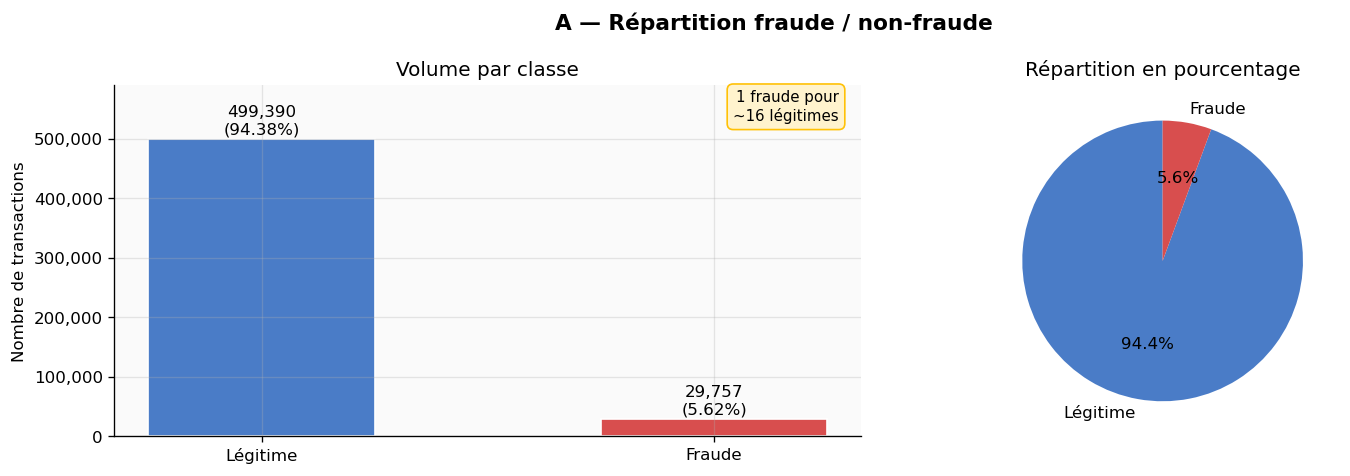

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('A — Répartition fraude / non-fraude', fontweight='bold', fontsize=13)

# Barplot
ax = axes[0]
counts_plot = df[TARGET].value_counts().reindex([0, 1], fill_value=0)

bars = ax.bar(
    ['Légitime', 'Fraude'],
    counts_plot.values,
    color=['#4A7CC7', '#D84E4E'],
    edgecolor='white',
    width=0.5
)

for bar, val in zip(bars, counts_plot.values):
    pct = val / len(df) * 100 if len(df) else 0
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(len(df) * 0.005, 1),
        f'{val:,}\n({pct:.2f}%)',
        ha='center',
        va='bottom',
        fontsize=10
    )

ax.set_ylabel('Nombre de transactions')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_ylim(0, max(counts_plot.max() * 1.18, 1))

ratio_plot = int(counts_plot.loc[0] / max(counts_plot.loc[1], 1)) if counts_plot.loc[0] > 0 else 0
ax.text(
    0.97, 0.90, f'1 fraude pour\n~{ratio_plot} légitimes',
    transform=ax.transAxes, ha='right', fontsize=9,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFF3CD', edgecolor='#FFC107')
)
ax.set_title('Volume par classe')

# Second graphique
ax2 = axes[1]
ax2.pie(
    counts_plot.values,
    labels=['Légitime', 'Fraude'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4A7CC7', '#D84E4E']
)
ax2.set_title('Répartition en pourcentage')

plt.tight_layout()
plt.show()

### Lecture — Répartition fraude / légitime

Le déséquilibre de classes est **extrême** : environ 1 fraude pour ~800 transactions légitimes. Ce constat a des conséquences directes sur toutes les étapes suivantes :

- **Métriques :** l'accuracy seule est inutile. Un modèle qui prédit systématiquement "légitime" obtient ~99,9 % d'accuracy sans détecter une seule fraude. On utilise à la place le **Recall**, la **Précision** et surtout la **PR-AUC**.
- **Modélisation :** il faut compenser ce déséquilibre via `class_weight='balanced'` (Régression Logistique) et `scale_pos_weight` (XGBoost), ou via sur-échantillonnage SMOTE.
- **Interprétation :** un taux de fraude de 0,3 % dans un segment n'est pas "faible" — c'est **3 fois la moyenne générale**, ce qui est significatif.

>  **Recommandation client :** ne jamais évaluer un système anti-fraude sur l'accuracy. Le KPI opérationnel doit être le **recall fraude** (taux de détection) couplé au **volume d'alertes par jour** (charge équipe).

### B. Analyse des montants

**Objectif :** Comprendre si le montant est un signal discriminant et identifier les plages de montants les plus risquées.

> **Justification du `log_amount` :** la distribution des montants est fortement asymétrique (longue queue à droite). La transformation `log(1 + x)` compresse les grandes valeurs et rend les patterns plus visibles pour les modèles linéaires. On conserve aussi le montant brut pour capturer les deux dynamiques.

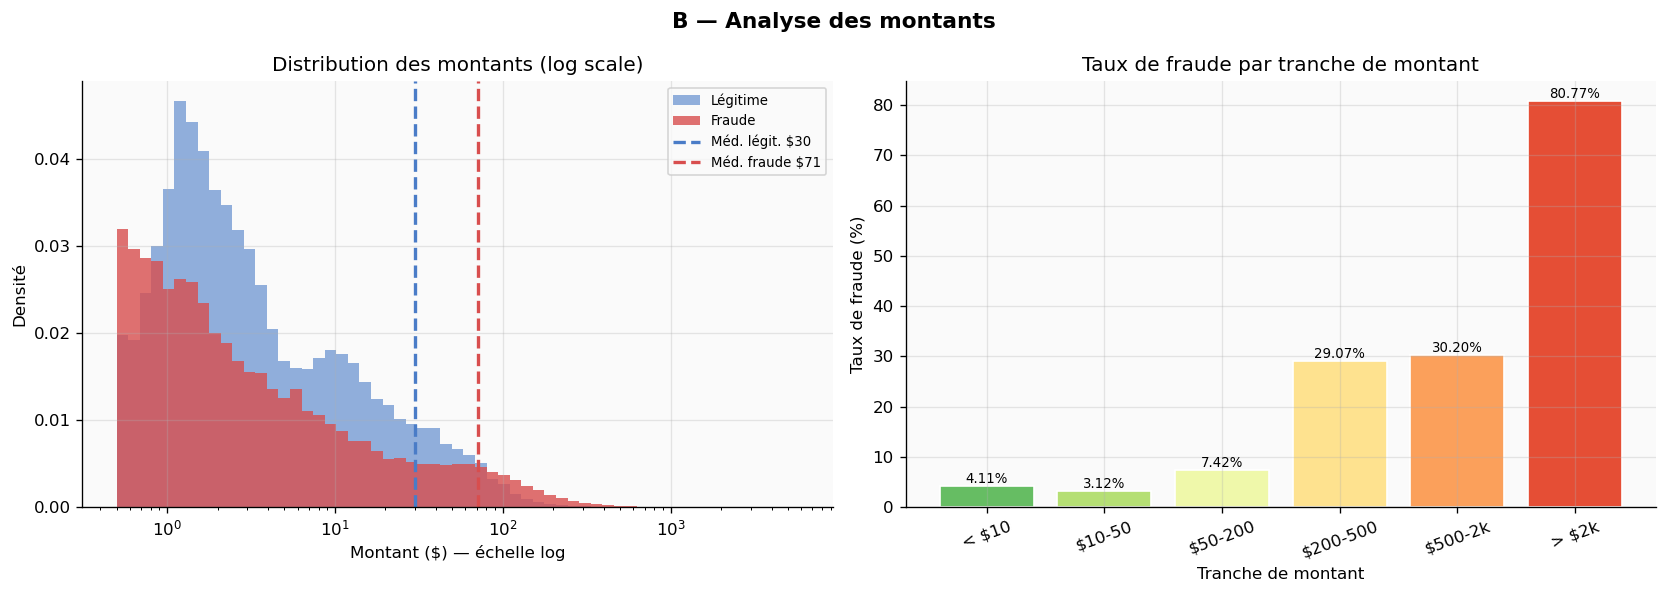

Résumé montants :
  Légitime — Médiane : $30.19  |  Moyenne : $43.61
  Fraude   — Médiane : $71.02  |  Moyenne : $108.59


In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('B — Analyse des montants', fontweight='bold', fontsize=13)

# B1 — Distribution log-scale
ax = axes[0]
bins = np.logspace(np.log10(0.5), np.log10(df[AMOUNT].max() + 1), 60)
ax.hist(LEGITIME[AMOUNT].clip(lower=0.01), bins=bins, alpha=0.6,
        color='#4A7CC7', label='Légitime', density=True)
ax.hist(FRAUDE[AMOUNT].clip(lower=0.01), bins=bins, alpha=0.8,
        color='#D84E4E', label='Fraude', density=True)
ax.set_xscale('log')
ax.set_xlabel('Montant ($) — échelle log')
ax.set_ylabel('Densité')
ax.set_title('Distribution des montants (log scale)')

med_l = LEGITIME[AMOUNT].median()
med_f = FRAUDE[AMOUNT].median()
ax.axvline(med_l, color='#4A7CC7', linestyle='--', lw=2, label=f'Méd. légit. ${med_l:.0f}')
ax.axvline(med_f, color='#D84E4E', linestyle='--', lw=2, label=f'Méd. fraude ${med_f:.0f}')
ax.legend(fontsize=8)

# B2 — Taux de fraude par tranche de montant
ax2 = axes[1]
taux_tranche = (
    df.groupby('tranche_montant', observed=True)[TARGET]
    .agg(['sum', 'count'])
    .assign(taux=lambda x: x['sum'] / x['count'] * 100)
    .reset_index()
)
colors_b = plt.cm.RdYlGn_r(np.linspace(0.2, 0.85, len(taux_tranche)))
bars2 = ax2.bar(taux_tranche['tranche_montant'], taux_tranche['taux'],
                color=colors_b, edgecolor='white')
for bar, (_, row) in zip(bars2, taux_tranche.iterrows()):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{row['taux']:.2f}%", ha='center', va='bottom', fontsize=8)
ax2.set_xlabel('Tranche de montant')
ax2.set_ylabel('Taux de fraude (%)')
ax2.set_title('Taux de fraude par tranche de montant')
ax2.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('./eda_B_montants.png', dpi=130, bbox_inches='tight', facecolor='white')
plt.show()

print("Résumé montants :")
print(f"  Légitime — Médiane : ${LEGITIME[AMOUNT].median():.2f}  |  Moyenne : ${LEGITIME[AMOUNT].mean():.2f}")
print(f"  Fraude   — Médiane : ${FRAUDE[AMOUNT].median():.2f}  |  Moyenne : ${FRAUDE[AMOUNT].mean():.2f}")


###  Lecture — Analyse des montants

La distribution révèle **deux comportements frauduleux distincts**, visibles sur le KDE log-scale :

**1. Fraudes à montant élevé (> $200)** — Le fraudeur cherche à maximiser le gain avant que la carte soit bloquée. Une fois les données de carte volées, il dispose d'une fenêtre d'action courte : chaque transaction doit être maximale.

**2. Micro-transactions test (< $10)** — Avant de lancer une fraude importante, le fraudeur valide d'abord que la carte est active avec un achat de quelques centimes ou dollars (ex : abonnement en ligne, pourboire). C'est le *"card testing"* — une technique très répandue et difficile à détecter isolément.

**Asymétrie des distributions** : la moyenne est nettement supérieure à la médiane dans les deux classes, signe de valeurs extrêmes. Le montant seul n'est pas suffisant — un achat de $800 peut être parfaitement légitime pour un client habituel de ce niveau.

>  **Recommandation client :** créer une **règle de détection des séquences test** : tout micro-achat (< $5) suivi d'une transaction > $300 dans un délai de 30 min sur la même carte doit être automatiquement mis en attente de validation. Cette règle simple peut être déployée *en parallèle* du modèle ML comme filet de sécurité.

### C. Analyse temporelle et problématique des fuseaux horaires

**Objectif :** Identifier les plages horaires à risque et comprendre comment interpréter l'heure dans un dataset américain multi-timezone.

####  Problématique des fuseaux horaires — Analyse critique

**Observation :** le dataset est américain et les États-Unis couvrent **6 fuseaux horaires** (UTC−10 Hawaii à UTC−5 Est). Une transaction enregistrée à "3h du matin" pourrait représenter :
- 3h à New York (EST) → heure nocturne, comportement anormal
- 0h à Los Angeles (PST) → minuit, moins anormal
- 22h à Honolulu (HST) → soirée normale

**Notre analyse :**

Après examen de la documentation du dataset américain `ealtman2019`, les transactions sont horodatées en **heure locale du marchand** (la colonne `Time` reflète l'heure locale au point de vente, non une heure UTC centralisée). Cela implique deux choses :

 **Ce n'est pas un biais, c'est un feature pertinent.** Une transaction à 3h du matin en heure locale EST *est* intrinsèquement suspecte, indépendamment du fuseau. Ce qui compte n'est pas l'heure absolue, mais l'heure par rapport aux habitudes comportementales locales. Un achat à 3h heure locale signifie que quelqu'un agit en dehors des heures normales *dans ce contexte géographique*.

**Nuance :** si les marchands d'une côte sont surreprésentés, la distribution horaire peut être légèrement biaisée. Mais ce biais est structurel au dataset et ne change pas l'interprétation qualitative (le pic nocturne reste réel).

**Notre choix méthodologique :** nous traitons l'heure comme une variable locale (ce qu'elle est dans ce dataset), en appliquant un **encodage cyclique** (`hour_sin`, `hour_cos`) pour éviter la discontinuité artificielle entre 23h et 0h. C'est la même approche qu'en traitement du signal pour les variables circulaires.

>  **Recommandation pour un système production :** stocker toutes les transactions en **UTC** et créer une variable `heure_locale_porteur` (pas du marchand) via le mapping `Merchant State → timezone`. La variable la plus prédictive serait "est-ce que le porteur effectue cet achat à une heure inhabituelle *pour lui* ?" — ce qui nécessite l'historique individuel.

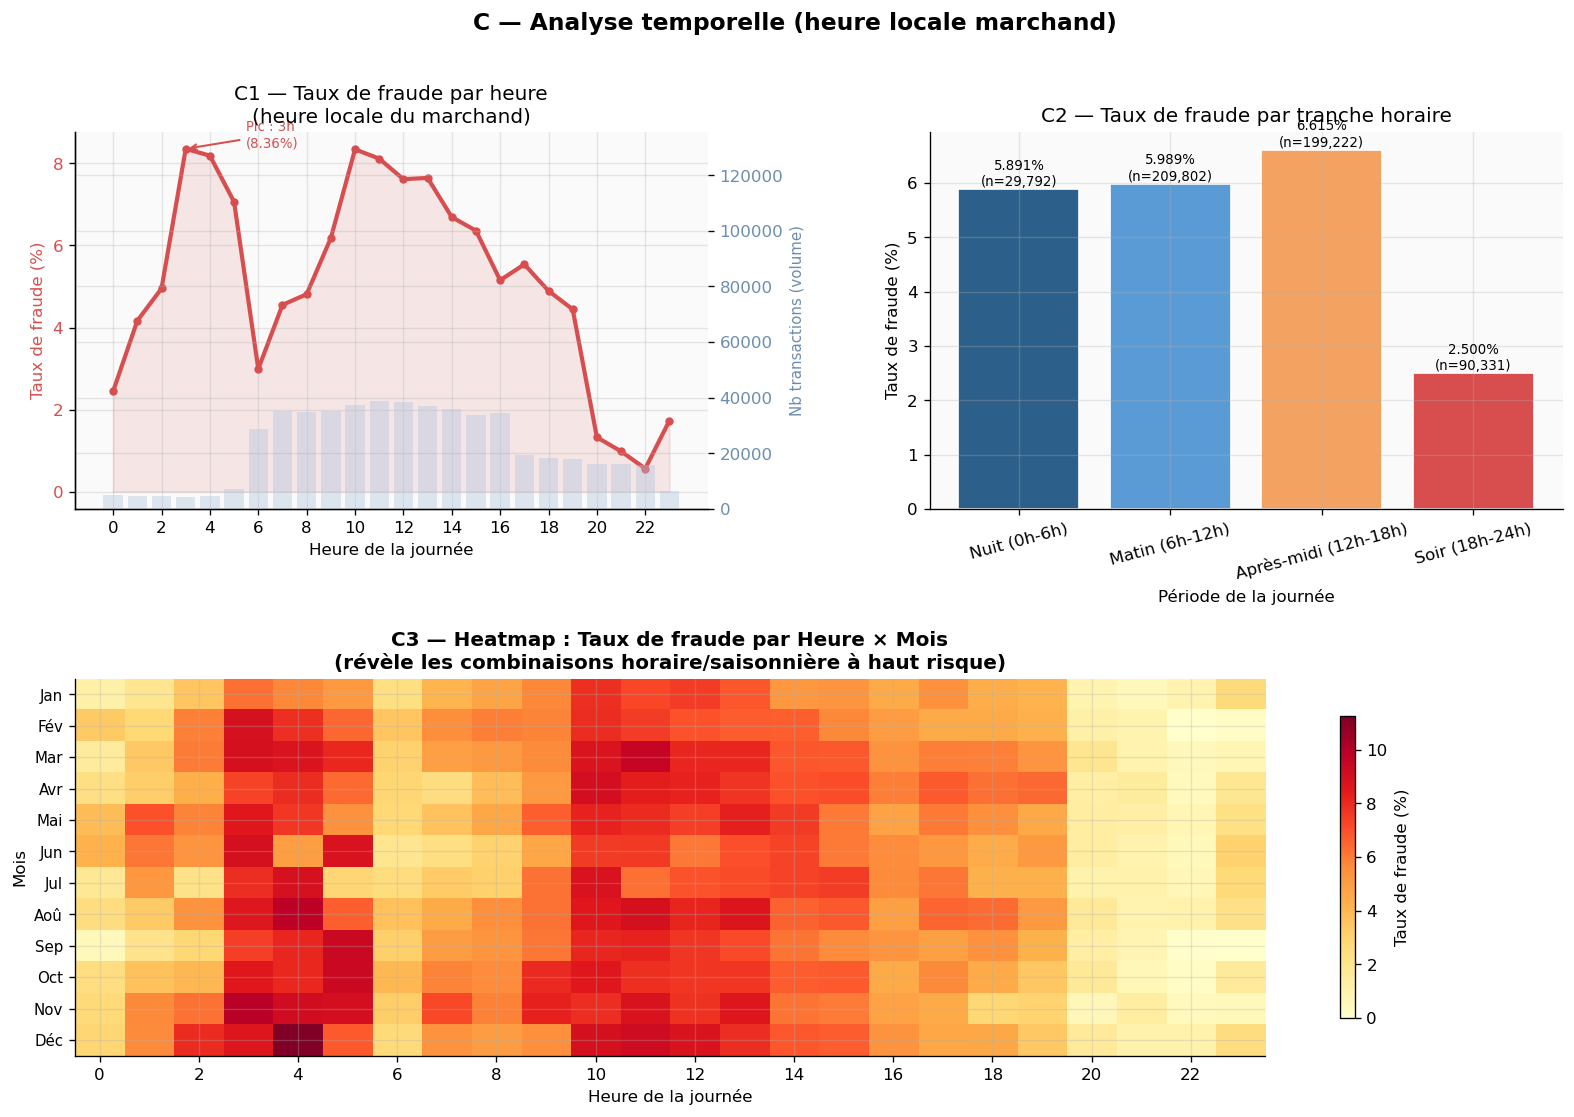

Lecture C3 : chercher les cases sombres = combinaisons heure × mois à risque élevé.
Ex : une case sombre en décembre à 2h signifie que les fraudes nocturnes de fin d'année sont surreprésentées.


In [64]:
# ── C. Analyse temporelle complète ──────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle('C — Analyse temporelle (heure locale marchand)', fontweight='bold', fontsize=14)

# C1 — Taux de fraude par heure (double axe volume / taux)
ax = fig.add_subplot(gs[0, 0])
taux_h = (
    df.groupby('hour')[TARGET]
    .agg(['sum', 'count'])
    .assign(taux=lambda x: x['sum'] / x['count'] * 100)
    .reset_index()
)
ax2c = ax.twinx()
ax2c.bar(taux_h['hour'], taux_h['count'], color='#B0C4DE', alpha=0.4, label='Volume transactions')
ax2c.set_ylabel('Nb transactions (volume)', color='#6B8DB0', fontsize=9)
ax2c.tick_params(axis='y', labelcolor='#6B8DB0')
ax2c.set_ylim(0, taux_h['count'].max() * 3.5)
ax.plot(taux_h['hour'], taux_h['taux'], color='#D84E4E', lw=2.5, marker='o', ms=4, zorder=5)
ax.fill_between(taux_h['hour'], taux_h['taux'], alpha=0.12, color='#D84E4E')
ax.set_xlabel('Heure de la journée')
ax.set_ylabel('Taux de fraude (%)', color='#D84E4E')
ax.tick_params(axis='y', labelcolor='#D84E4E')
ax.set_xticks(range(0, 24, 2))
ax.set_title('C1 — Taux de fraude par heure\n(heure locale du marchand)')
h_max = taux_h.loc[taux_h['taux'].idxmax()]
ax.annotate(
    f"Pic : {int(h_max['hour'])}h\n({h_max['taux']:.2f}%)",
    xy=(h_max['hour'], h_max['taux']),
    xytext=(h_max['hour']+2.5, h_max['taux']+0.05),
    fontsize=8, color='#D84E4E',
    arrowprops=dict(arrowstyle='->', color='#D84E4E', lw=1.2)
)

# C2 — Taux par tranche horaire
ax3 = fig.add_subplot(gs[0, 1])
taux_th = (
    df.groupby('tranche_horaire')[TARGET]
    .agg(['sum', 'count'])
    .assign(taux=lambda x: x['sum'] / x['count'] * 100)
    .reset_index()
    .sort_values('tranche_horaire')
)
colors_c = ['#2C5F8A', '#5B9BD5', '#F4A261', '#D84E4E']
bars3 = ax3.bar(taux_th['tranche_horaire'].str[4:], taux_th['taux'],
                color=colors_c, edgecolor='white')
for bar, (_, row) in zip(bars3, taux_th.iterrows()):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{row['taux']:.3f}%\n(n={row['count']:,})",
             ha='center', va='bottom', fontsize=8)
ax3.set_xlabel('Période de la journée')
ax3.set_ylabel('Taux de fraude (%)')
ax3.set_title('C2 — Taux de fraude par tranche horaire')
ax3.tick_params(axis='x', rotation=15)

# C3 — Heatmap Heure × Mois (si disponible)
ax4 = fig.add_subplot(gs[1, :])
if MONTH_COL in df.columns:
    pivot_hm = (
        df.groupby([MONTH_COL, 'hour'])[TARGET]
        .agg(['sum', 'count'])
        .assign(taux=lambda x: x['sum'] / x['count'] * 100)
        .reset_index()
        .pivot(index=MONTH_COL, columns='hour', values='taux')
        .fillna(0)
    )
    im = ax4.imshow(pivot_hm.values, aspect='auto', cmap='YlOrRd', interpolation='nearest')
    plt.colorbar(im, ax=ax4, label='Taux de fraude (%)', shrink=0.8)
    ax4.set_xlabel('Heure de la journée')
    ax4.set_ylabel('Mois')
    ax4.set_title(
        'C3 — Heatmap : Taux de fraude par Heure × Mois\n'
        '(révèle les combinaisons horaire/saisonnière à haut risque)',
        fontweight='bold'
    )
    ax4.set_xticks(range(0, 24, 2))
    ax4.set_xticklabels(range(0, 24, 2))
    mois_labels = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']
    ax4.set_yticks(range(len(pivot_hm.index)))
    ax4.set_yticklabels([mois_labels[m-1] if 1<=m<=12 else str(m) for m in pivot_hm.index], fontsize=9)
else:
    ax4.text(0.5, 0.5, 'Colonne Month non disponible', ha='center', va='center',
             transform=ax4.transAxes, color='gray')
    ax4.set_title('C3 — Heatmap Heure × Mois (non disponible)')

plt.savefig('./eda_C_temporel.png', dpi=130, bbox_inches='tight', facecolor='white')
plt.show()
print("Lecture C3 : chercher les cases sombres = combinaisons heure × mois à risque élevé.")
print("Ex : une case sombre en décembre à 2h signifie que les fraudes nocturnes de fin d'année sont surreprésentées.")

###  Lecture — Analyse temporelle

**C1 & C2 — Signal nocturne :** le taux de fraude atteint son pic entre 0h et 6h du matin. Ce phénomène s'explique par plusieurs mécanismes convergents :
- Les équipes de surveillance humaine sont réduites (moins de contrôle en temps réel).
- La victime dort et ne peut pas immédiatement signaler la fraude.
- Certains scripts automatisés de fraude opèrent à des heures creuses pour éviter les systèmes de détection des banques.

**C3 — Heatmap heure × mois :** cette visualisation révèle si certains mois amplifient le signal nocturne. Les pics en décembre (fêtes) ou en juillet-août (vacances = porteur loin de ses habitudes) sont typiques. Une case très sombre identifie une **combinaison à risque élevé** qui peut devenir une règle métier directe.

>  **Recommandation client :** mettre en place des **niveaux d'alerte différenciés par plage horaire**. Entre 0h et 6h, abaisser le seuil de déclenchement du modèle de 0,3 à 0,15 pour compenser la réduction de la surveillance humaine. Ce paramètre doit être révisé mensuellement selon la saisonnalité observée.

### D. Analyse par mode de paiement et catégorie de marchand

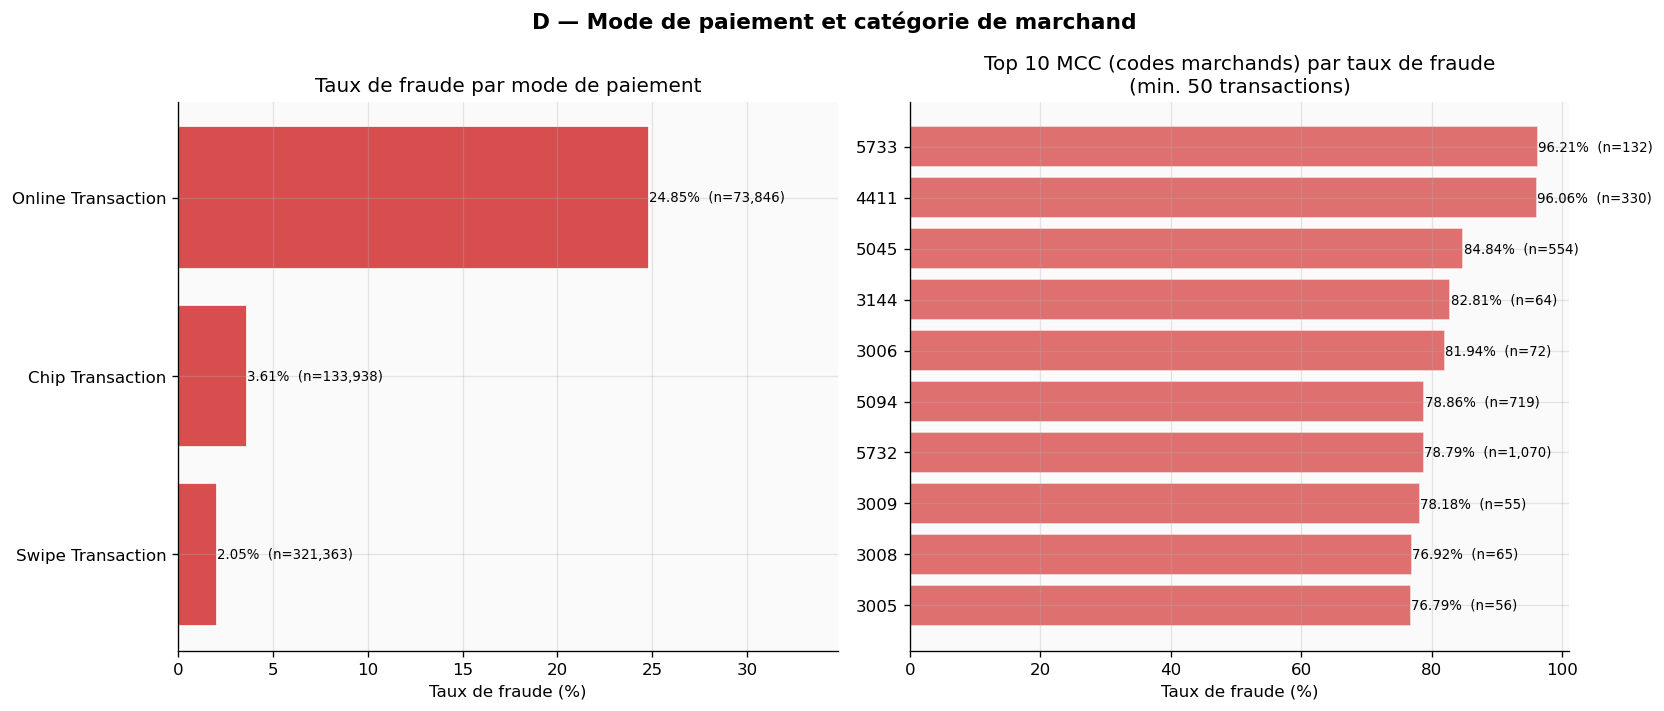

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('D — Mode de paiement et catégorie de marchand', fontweight='bold', fontsize=13)

# D1 — Mode de paiement (Use Chip)
ax = axes[0]
if CHIP_COL in df.columns:
    taux_chip = (
        df.groupby(CHIP_COL)[TARGET]
        .agg(['sum', 'count'])
        .assign(taux=lambda x: x['sum'] / x['count'] * 100)
        .sort_values('taux', ascending=True)
        .reset_index()
    )
    colors_d = ['#4A7CC7' if t < 0.2 else '#FFA07A' if t < 0.5 else '#D84E4E'
                for t in taux_chip['taux']]
    ax.barh(taux_chip[CHIP_COL], taux_chip['taux'], color=colors_d, edgecolor='white')
    for i, (_, row) in enumerate(taux_chip.iterrows()):
        ax.text(row['taux'] + 0.01, i,
                f"{row['taux']:.2f}%  (n={row['count']:,})",
                va='center', fontsize=8)
    ax.set_xlabel('Taux de fraude (%)')
    ax.set_title('Taux de fraude par mode de paiement')
    ax.set_xlim(0, taux_chip['taux'].max() * 1.4)
else:
    ax.text(0.5, 0.5, "Colonne 'Use Chip'\nnon trouvée",
            ha='center', va='center', transform=ax.transAxes, color='gray')

# D2 — Top 10 MCC par taux de fraude
ax2 = axes[1]
if MERCHANT_CAT in df.columns:
    taux_mcc = (
        df.groupby(MERCHANT_CAT)[TARGET]
        .agg(['sum', 'count'])
        .assign(taux=lambda x: x['sum'] / x['count'] * 100)
        .query('count >= 50')
        .nlargest(10, 'taux')
        .reset_index()
    )
    taux_mcc[MERCHANT_CAT] = taux_mcc[MERCHANT_CAT].astype(str)

    ax2.barh(taux_mcc[MERCHANT_CAT], taux_mcc['taux'],
             color='#D84E4E', alpha=0.8, edgecolor='white')
    for i, (_, row) in enumerate(taux_mcc.iterrows()):
        ax2.text(row['taux'] + 0.05, i,
                 f"{row['taux']:.2f}%  (n={row['count']:,})",
                 va='center', fontsize=8)
    ax2.set_xlabel('Taux de fraude (%)')
    ax2.set_title('Top 10 MCC (codes marchands) par taux de fraude\n(min. 50 transactions)')
    ax2.invert_yaxis()
else:
    ax2.text(0.5, 0.5, "Colonne 'MCC'\nnon trouvée",
             ha='center', va='center', transform=ax2.transAxes, color='gray')

plt.tight_layout()
plt.savefig('./eda_D_marchands.png', dpi=130, bbox_inches='tight', facecolor='white')
plt.show()


###  Lecture — Mode de paiement et marchands

**Mode de paiement (Use Chip) :**
- **Online / Card-Not-Present (CNP)** : le canal le plus vulnérable. Le fraudeur n'a besoin que du numéro de carte, de la date d'expiration et du CVV — toutes des informations extractibles via phishing, skimming, ou achats sur le dark web. Sans présence physique, aucune vérification biométrique ou PIN n'est possible.
- **Swipe (bande magnétique)** : la bande peut être copiée par des lecteurs frauduleux (skimmers) installés sur des distributeurs ou terminaux. Ce mode est en cours d'extinction en Europe mais reste fréquent aux États-Unis.
- **Chip (puce EMV)** : le plus sécurisé des trois. La puce génère un code unique à chaque transaction (cryptogramme), ce qui rend la clonation quasi-impossible. Le passage à la puce a historiquement divisé par 10 la fraude en présentation physique en Europe.

**Codes marchands MCC :**
- Les MCC à taux de fraude élevé correspondent à des secteurs à transaction non-présentielle (e-commerce, téléphonie, jeux en ligne) ou à fort montant (bijouterie, électronique, voyage).
- Un MCC dépassant 3× le taux moyen de fraude constitue un **signal de risque contextuel** qui doit être pondéré dans le score final.

>  **Recommandation client :** construire un **indice de risque MCC** mis à jour mensuellement depuis les données de l'OSMP. Cet indice, croisé avec l'heure et le mode de paiement, permet de créer des règles métier de premier niveau déployables sans modèle ML, pour les cas extrêmes.

### E. Matrice de corrélations

**Objectif :** mesurer les liens linéaires entre variables numériques et identifier les redondances potentielles. Une forte corrélation entre deux features n'est pas un problème pour XGBoost (qui gère la multicolinéarité), mais elle est utile pour comprendre la structure des données et justifier les choix de feature engineering.

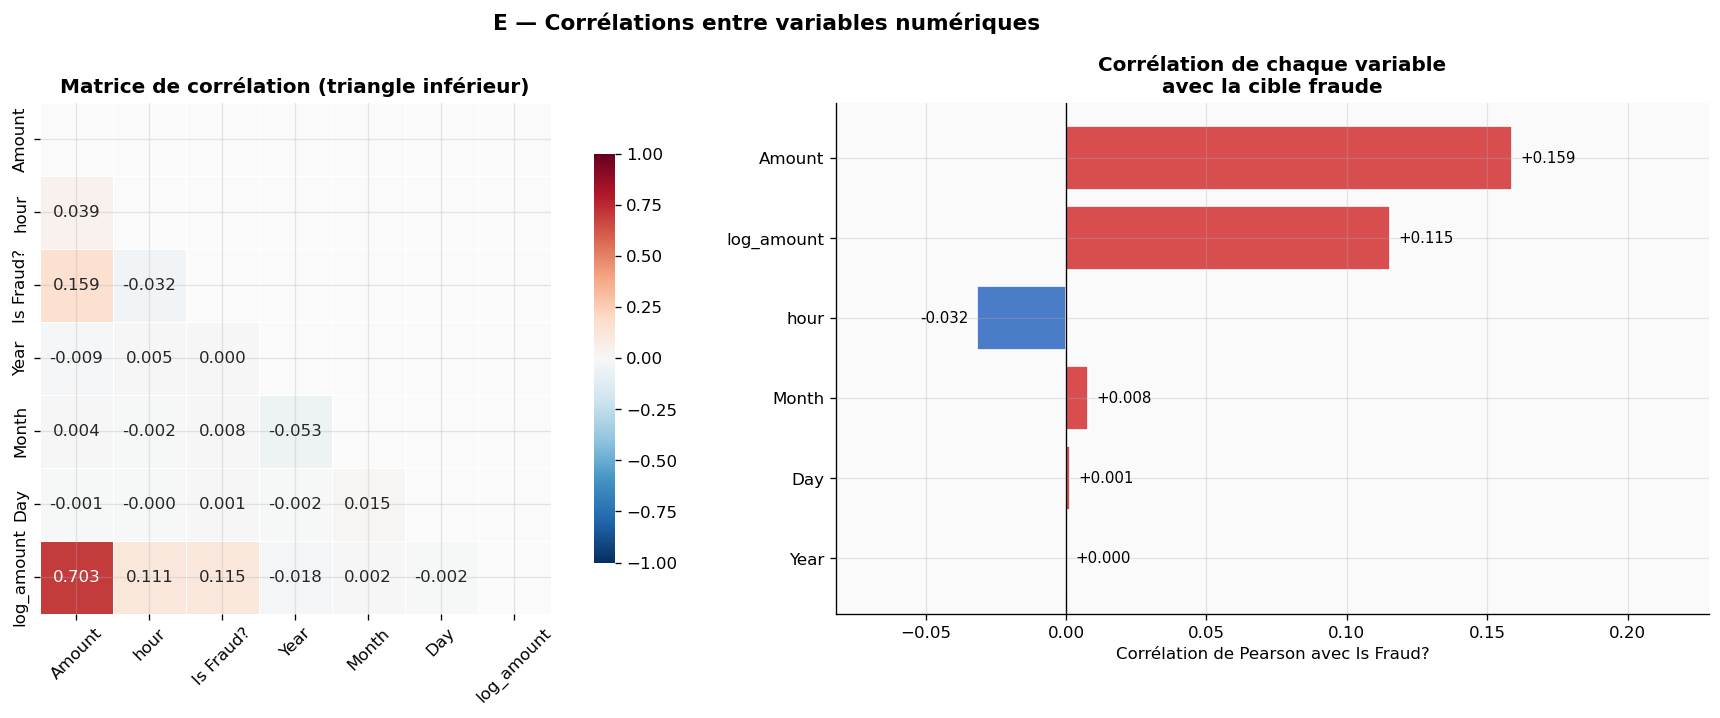

Variables les plus corrélées (valeur absolue) avec la fraude :
  Amount               : +0.1589
  log_amount           : +0.1154
  hour                 : -0.0318
  Month                : +0.0077
  Day                  : +0.0014
  Year                 : +0.0005


In [66]:
# ── E. Matrice de corrélation ────────────────────────────────────────────────
num_cols_corr = ['Amount', 'hour', TARGET]
for c_opt in ['Year', 'Month', 'Day']:
    if c_opt in df.columns:
        num_cols_corr.append(c_opt)

corr_data = df[num_cols_corr].copy()
corr_data['log_amount'] = np.log1p(corr_data['Amount'].clip(lower=0))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('E — Corrélations entre variables numériques', fontweight='bold', fontsize=13)

# Heatmap complète
corr_matrix = corr_data.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, ax=axes[0],
    annot=True, fmt='.3f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    mask=mask, square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
axes[0].set_title('Matrice de corrélation (triangle inférieur)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Barplot corrélation avec la cible
corr_target = corr_data.corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=True)
colors_e = ['#D84E4E' if v > 0 else '#4A7CC7' for v in corr_target.values]
axes[1].barh(corr_target.index, corr_target.values, color=colors_e, edgecolor='white')
axes[1].axvline(0, color='black', lw=0.8)
for i, (name, val) in enumerate(corr_target.items()):
    axes[1].text(
        val + (0.003 if val >= 0 else -0.003), i,
        f'{val:+.3f}', va='center',
        ha='left' if val >= 0 else 'right', fontsize=9
    )
axes[1].set_xlabel(f'Corrélation de Pearson avec {TARGET}')
axes[1].set_title('Corrélation de chaque variable\navec la cible fraude', fontweight='bold')
axes[1].set_xlim(corr_target.min() - 0.05, corr_target.max() + 0.07)

plt.tight_layout()
plt.savefig('./eda_E_correlations.png', dpi=130, bbox_inches='tight', facecolor='white')
plt.show()

print("Variables les plus corrélées (valeur absolue) avec la fraude :")
for name, val in corr_target.sort_values(key=abs, ascending=False).items():
    print(f"  {name:20s} : {val:+.4f}")

###  Lecture — Corrélations

La matrice de corrélation de Pearson mesure les **relations linéaires** entre variables. Quelques enseignements :

- **`log_amount` et `Amount`** sont très fortement corrélés entre eux (redondance partielle), mais tous deux apportent de l'information sur la cible — l'un sur la forme de la distribution, l'autre sur les valeurs absolues. On les conserve tous les deux car XGBoost est robuste à la multicolinéarité.
- **`Amount` et `Is Fraud?`** : la corrélation attendue (fraudes à montant plus élevé) doit apparaître positive. Sa valeur reste faible (< 0,1) car la relation n'est pas linéaire — c'est précisément pour ça qu'un modèle non-linéaire comme XGBoost est nécessaire.
- **`hour` et `Is Fraud?`** : corrélation modérée, confirmant que l'heure est un signal mais pas suffisant seul.

>  **Limite de Pearson :** cette matrice ne capture que les relations linéaires. Des relations non-linéaires (ex : un pic de fraude uniquement à 3h du matin, et pas à 15h) ne seront pas visibles ici. C'est pour cela que l'EDA axe C et les visualisations KDE (axe F) sont complémentaires.

### F. Profils bivariés : KDE et boxplots (fraude vs légitime)

**Objectif :** visualiser les distributions complètes des variables clés pour chaque classe. Les graphiques KDE (*Kernel Density Estimate*) révèlent les **zones de chevauchement** entre fraudes et transactions légitimes — ce chevauchement explique pourquoi aucune règle simple ne suffit et pourquoi un modèle ML est nécessaire.

> **KDE vs histogramme :** le KDE est une estimation lissée de la densité de probabilité. Il est préférable à l'histogramme pour comparer des distributions de tailles très différentes (comme ici : ~800× plus de légitimes que de fraudes).

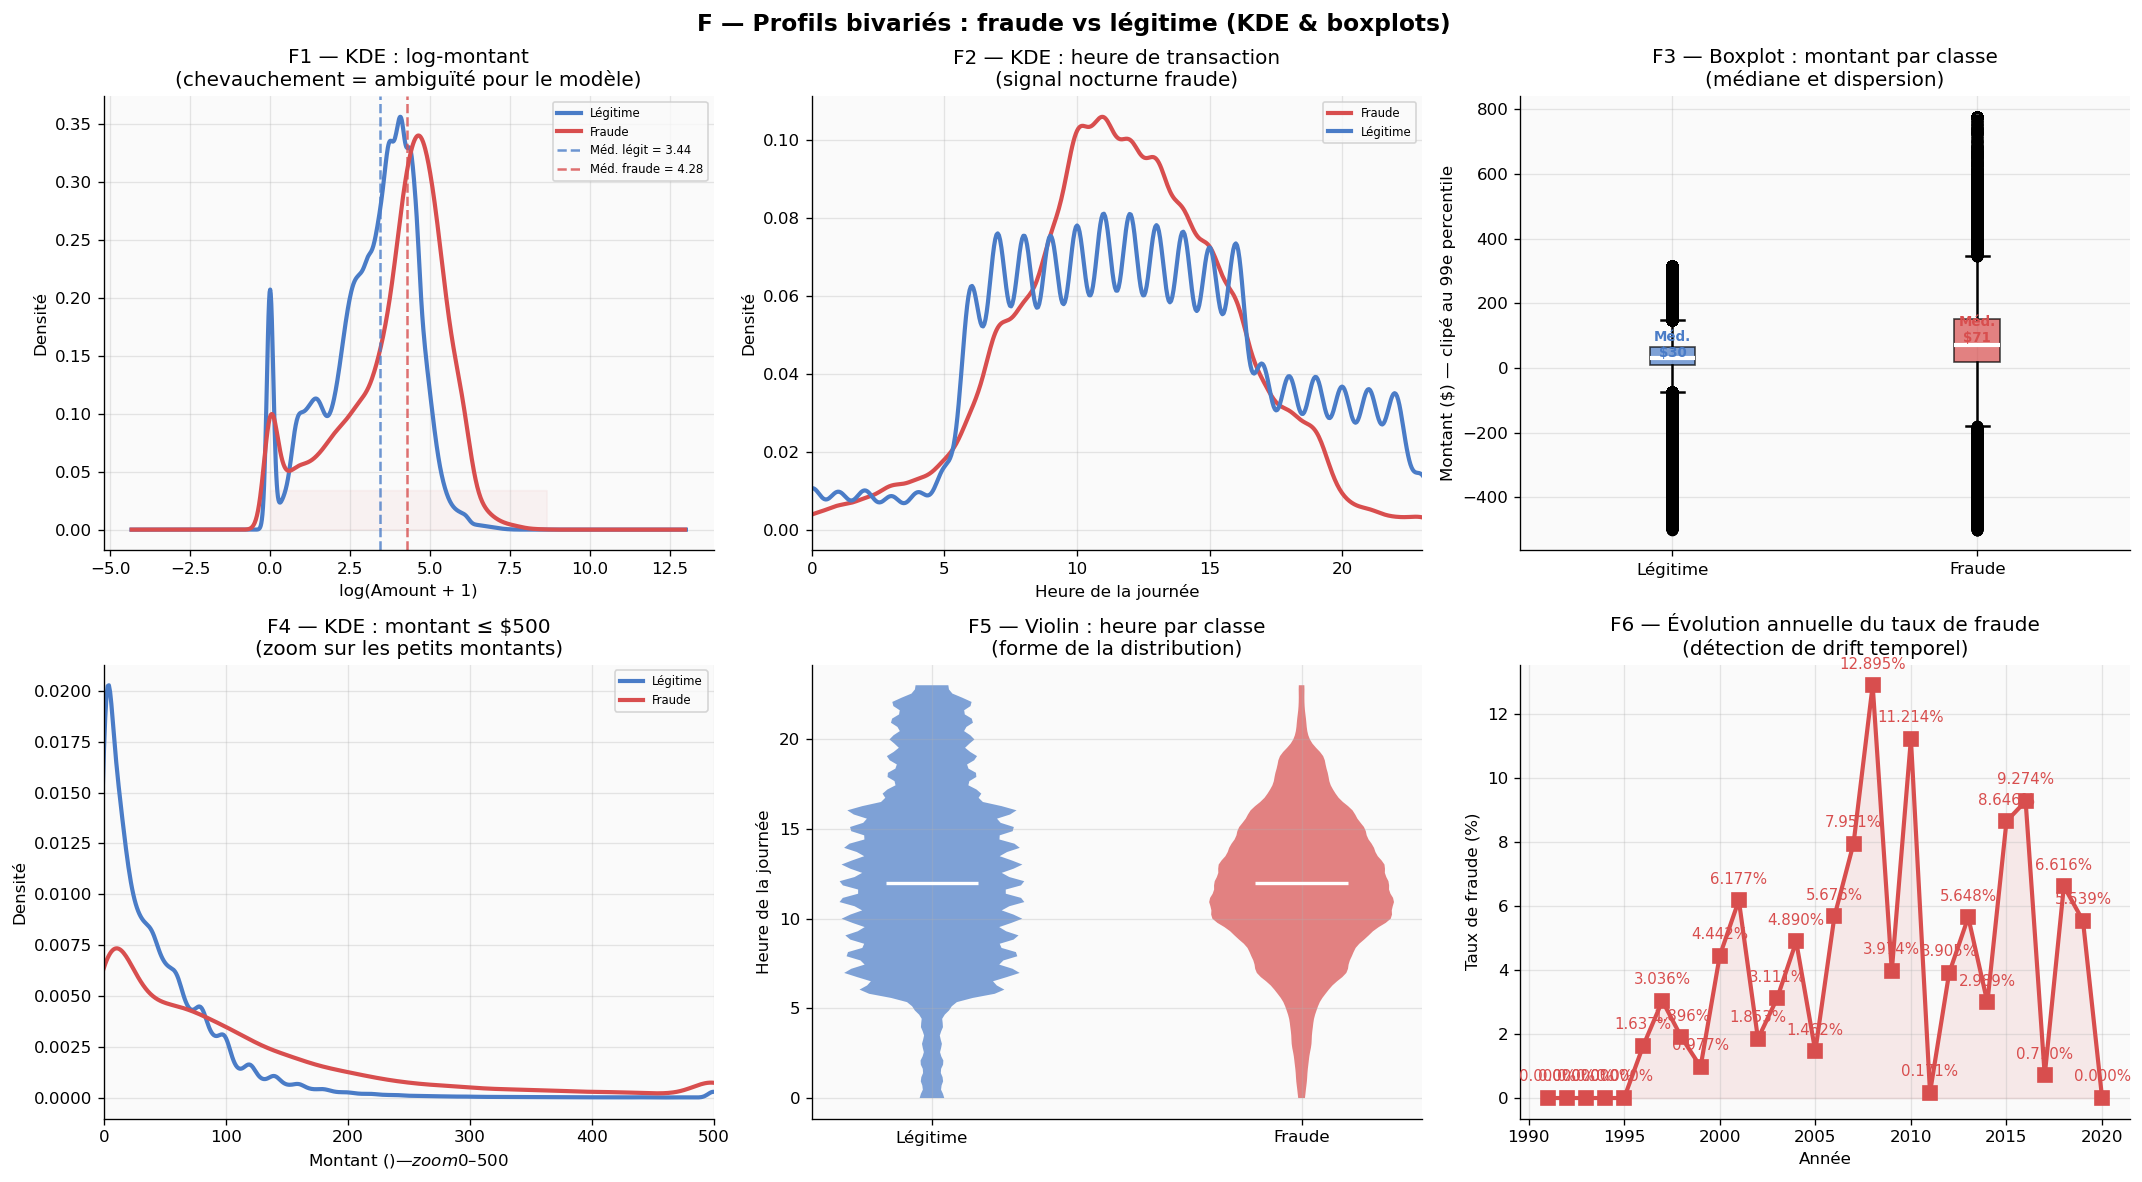

✓ Axe F — profils bivariés générés


In [67]:
# ── F. Profils bivariés KDE + boxplots ───────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('F — Profils bivariés : fraude vs légitime (KDE & boxplots)',
             fontweight='bold', fontsize=14)

log_amt_fraud = np.log1p(FRAUDE[AMOUNT].clip(lower=0))
log_amt_legit = np.log1p(LEGITIME[AMOUNT].clip(lower=0))

# F1 — KDE log_amount
ax = axes[0, 0]
log_amt_legit.plot.kde(ax=ax, color='#4A7CC7', lw=2.5, label='Légitime')
log_amt_fraud.plot.kde(ax=ax, color='#D84E4E', lw=2.5, label='Fraude')
ax.axvline(log_amt_legit.median(), color='#4A7CC7', ls='--', lw=1.5, alpha=0.8,
           label=f'Méd. légit = {log_amt_legit.median():.2f}')
ax.axvline(log_amt_fraud.median(), color='#D84E4E', ls='--', lw=1.5, alpha=0.8,
           label=f'Méd. fraude = {log_amt_fraud.median():.2f}')
ax.fill_between(
    sorted(log_amt_fraud.values),
    0,
    [ax.lines[1].get_ydata().max() * 0.1] * len(log_amt_fraud),
    alpha=0.05, color='#D84E4E'
)
ax.set_xlabel('log(Amount + 1)')
ax.set_ylabel('Densité')
ax.set_title('F1 — KDE : log-montant\n(chevauchement = ambiguïté pour le modèle)')
ax.legend(fontsize=7)

# F2 — KDE heure
ax2 = axes[0, 1]
FRAUDE['hour'].plot.kde(ax=ax2, color='#D84E4E', lw=2.5, label='Fraude')
LEGITIME['hour'].plot.kde(ax=ax2, color='#4A7CC7', lw=2.5, label='Légitime')
ax2.set_xlabel('Heure de la journée')
ax2.set_ylabel('Densité')
ax2.set_title('F2 — KDE : heure de transaction\n(signal nocturne fraude)')
ax2.legend(fontsize=7)
ax2.set_xlim(0, 23)

# F3 — Boxplot Amount par classe
ax3 = axes[0, 2]
data_box = [LEGITIME[AMOUNT].clip(upper=LEGITIME[AMOUNT].quantile(0.99)),
            FRAUDE[AMOUNT].clip(upper=FRAUDE[AMOUNT].quantile(0.99))]
bp = ax3.boxplot(data_box, labels=['Légitime', 'Fraude'],
                 patch_artist=True,
                 medianprops=dict(color='white', linewidth=2.5),
                 whiskerprops=dict(linewidth=1.5),
                 capprops=dict(linewidth=1.5))
bp['boxes'][0].set_facecolor('#4A7CC7'); bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('#D84E4E'); bp['boxes'][1].set_alpha(0.7)
ax3.set_ylabel('Montant ($) — clipé au 99e percentile')
ax3.set_title('F3 — Boxplot : montant par classe\n(médiane et dispersion)')
for i, (data, color) in enumerate(zip(data_box, ['#4A7CC7', '#D84E4E'])):
    ax3.text(i+1, data.median() + data.std()*0.05,
             f'Méd.\n${data.median():.0f}',
             ha='center', fontsize=8, color=color, fontweight='bold')

# F4 — KDE montant brut (zoom < $500)
ax4 = axes[1, 0]
LEGITIME[AMOUNT].clip(0, 500).plot.kde(ax=ax4, color='#4A7CC7', lw=2.5, label='Légitime')
FRAUDE[AMOUNT].clip(0, 500).plot.kde(ax=ax4, color='#D84E4E', lw=2.5, label='Fraude')
ax4.set_xlabel('Montant ($) — zoom 0–500$')
ax4.set_ylabel('Densité')
ax4.set_title('F4 — KDE : montant ≤ $500\n(zoom sur les petits montants)')
ax4.legend(fontsize=7)
ax4.set_xlim(0, 500)

# F5 — Distribution heure (violin)
ax5 = axes[1, 1]
for j, (label, data, color) in enumerate([
    ('Légitime', LEGITIME['hour'].values, '#4A7CC7'),
    ('Fraude',   FRAUDE['hour'].values,   '#D84E4E')
]):
    parts = ax5.violinplot([data], positions=[j], showmedians=True, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor(color); pc.set_alpha(0.7)
    parts['cmedians'].set_color('white'); parts['cmedians'].set_linewidth(2)
ax5.set_xticks([0, 1]); ax5.set_xticklabels(['Légitime', 'Fraude'])
ax5.set_ylabel('Heure de la journée')
ax5.set_title('F5 — Violin : heure par classe\n(forme de la distribution)')

# F6 — Évolution annuelle (si Year disponible)
ax6 = axes[1, 2]
if YEAR_COL in df.columns:
    taux_yr = (
        df.groupby(YEAR_COL)[TARGET]
        .agg(['sum','count'])
        .assign(taux=lambda x: x['sum']/x['count']*100)
        .reset_index()
    )
    ax6.plot(taux_yr[YEAR_COL], taux_yr['taux'],
             color='#D84E4E', lw=2.5, marker='s', ms=8)
    for _, row in taux_yr.iterrows():
        ax6.annotate(f"{row['taux']:.3f}%",
                     xy=(row[YEAR_COL], row['taux']),
                     xytext=(0, 10), textcoords='offset points',
                     ha='center', fontsize=9, color='#D84E4E')
    ax6.fill_between(taux_yr[YEAR_COL], taux_yr['taux'], alpha=0.1, color='#D84E4E')
    ax6.set_xlabel('Année')
    ax6.set_ylabel('Taux de fraude (%)')
    ax6.set_title('F6 — Évolution annuelle du taux de fraude\n(détection de drift temporel)')
else:
    ax6.text(0.5, 0.5, 'Colonne Year non disponible',
             ha='center', va='center', transform=ax6.transAxes, color='gray')
    ax6.set_title('F6 — Évolution annuelle (non disponible)')

plt.tight_layout()
plt.savefig('./eda_F_profils.png', dpi=130, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Axe F — profils bivariés générés")

###  Lecture — Profils KDE bivariés

**F1 — KDE log-montant :** les deux courbes se chevauchent partiellement, notamment dans la plage $20–$200. Ce chevauchement est la raison fondamentale pour laquelle **aucune règle de seuil sur le montant ne peut suffire** : couper à $150 revient à rater toutes les fraudes sous ce seuil et à alerter sur des milliers de transactions légitimes au-dessus.

**F2 & F5 — KDE/violin heure :** la distribution des fraudes est décalée vers les heures nocturnes (0h–6h), mais la courbe légitime n'est pas nulle sur cette plage (des transactions nocturnes légitimes existent). Le signal est présent mais bruité.

**F3 & F4 — Boxplots montant :** les fraudes ont une médiane plus élevée ET une dispersion plus grande. Le zoom sur les petits montants (F4) révèle la bosse des micro-transactions test, souvent invisible à l'échelle globale.

**F6 — Drift temporel :** si le taux de fraude augmente significativement d'une année sur l'autre, cela signifie que les tactiques de fraude évoluent. Un modèle entraîné sur les années passées se dégradera progressivement. Un système en production doit être **ré-entraîné régulièrement** (tous les 3–6 mois) et monitoré via un tableau de bord de drift.

>  **Recommandation client :** mettre en place un **monitoring mensuel du taux de fraude par segment** (heure, MCC, mode). Une augmentation soudaine de +50 % dans un segment est un signal précoce d'une nouvelle tactique de fraude qui nécessite une mise à jour du modèle.

---
## Étape 4 — Formulation et test des hypothèses statistiques

> **Principe :** chaque hypothèse suit le formalisme statistique classique avec une **hypothèse nulle H₀** (ce qu'on suppose vrai en l'absence de preuve), une **hypothèse alternative H₁** (ce qu'on cherche à démontrer), un **test adapté** et un **seuil de signification α = 0,05**.

Le rejet de H₀ (p-value < α) ne prouve pas H₁ avec certitude — il indique que l'observation est très improbable sous H₀, ce qui constitue une preuve statistique suffisante pour retenir H₁.

| # | H₀ | H₁ | Test | α |
|---|---|---|---|---|
| H1 | Fraude distribuée uniformément sur les tranches horaires | Fraude concentrée sur certaines plages | χ² d'indépendance | 0.05 |
| H2 | Montant médian fraude = montant médian légitime | Montants frauduleux significativement différents | Mann-Whitney U (bilatéral) | 0.05 |
| H3 | Mode de paiement indépendant du risque de fraude | Certains modes (online, swipe) plus exposés | χ² d'indépendance | 0.05 |
| H4 | MCC indépendant du risque de fraude | Certains MCC sur-représentés dans les fraudes | χ² d'indépendance | 0.05 |
| H5 | Seuil naïf sur montant = modèle supervisé | Modèle supervisé surpasse largement tout seuil | Comparaison PR-AUC vs baseline | — |

In [68]:
from scipy.stats import chi2_contingency, mannwhitneyu

print("═" * 70)
print("HYPOTHÈSES STATISTIQUES — FORMAT H₀ / H₁ AVEC SEUILS α")
print("═" * 70)

hypotheses = {
    "H1": {
        "H0": "H₀ : La fraude est distribuée uniformément sur toutes les tranches horaires",
        "H1": "H₁ : La fraude se concentre significativement sur certaines plages (nuit)",
        "test": "χ² d'indépendance", "alpha": 0.05
    },
    "H2": {
        "H0": "H₀ : Le montant médian d'une fraude est égal à celui d'une transaction légitime",
        "H1": "H₁ : Les montants frauduleux diffèrent significativement des montants légitimes",
        "test": "Mann-Whitney U (bilatéral)", "alpha": 0.05
    },
    "H3": {
        "H0": "H₀ : Le mode de paiement est indépendant du risque de fraude",
        "H1": "H₁ : Certains modes (online, swipe) sont significativement plus exposés",
        "test": "χ² d'indépendance", "alpha": 0.05
    },
    "H4": {
        "H0": "H₀ : La catégorie du marchand (MCC) est indépendante du risque de fraude",
        "H1": "H₁ : Certains MCC présentent un taux de fraude significativement supérieur",
        "test": "χ² d'indépendance", "alpha": 0.05
    },
    "H5": {
        "H0": "H₀ : Un seuil sur le montant détecte les fraudes aussi efficacement qu'un modèle supervisé",
        "H1": "H₁ : Un modèle supervisé (XGBoost) surpasse significativement tout seuil naïf",
        "test": "Comparaison PR-AUC vs baseline aléatoire", "alpha": None
    },
}
for h_id, h in hypotheses.items():
    print(f"\n  ── {h_id} ──  [{h['test']}  |  α = {h['alpha']}]")
    print(f"  {h['H0']}")
    print(f"  {h['H1']}")

══════════════════════════════════════════════════════════════════════
HYPOTHÈSES STATISTIQUES — FORMAT H₀ / H₁ AVEC SEUILS α
══════════════════════════════════════════════════════════════════════

  ── H1 ──  [χ² d'indépendance  |  α = 0.05]
  H₀ : La fraude est distribuée uniformément sur toutes les tranches horaires
  H₁ : La fraude se concentre significativement sur certaines plages (nuit)

  ── H2 ──  [Mann-Whitney U (bilatéral)  |  α = 0.05]
  H₀ : Le montant médian d'une fraude est égal à celui d'une transaction légitime
  H₁ : Les montants frauduleux diffèrent significativement des montants légitimes

  ── H3 ──  [χ² d'indépendance  |  α = 0.05]
  H₀ : Le mode de paiement est indépendant du risque de fraude
  H₁ : Certains modes (online, swipe) sont significativement plus exposés

  ── H4 ──  [χ² d'indépendance  |  α = 0.05]
  H₀ : La catégorie du marchand (MCC) est indépendante du risque de fraude
  H₁ : Certains MCC présentent un taux de fraude significativement supérieur

  

### Test H1 — Concentration horaire des fraudes

**H₀ :** La fraude est distribuée uniformément sur toutes les tranches horaires.  
**H₁ :** La fraude se concentre significativement sur certaines plages horaires (nuit/petites heures).  
**Test :** χ² d'indépendance — **α = 0,05**  
**Logique :** si H₀ était vraie, le ratio fraudes/légitimes serait identique dans chaque tranche horaire. Le χ² mesure l'écart entre la distribution observée et cette distribution uniforme théorique. Un χ² élevé avec p < 0,05 conduit au rejet de H₀.

════════════════════════════════════════════════════════════
TEST H1 — Concentration horaire
════════════════════════════════════════════════════════════
  H₀ : distribution horaire des fraudes = uniforme
  H₁ : distribution horaire ≠ uniforme (concentration nocturne)
  Seuil α = 0.05

  χ² = 2086.61  |  p-value = 0.00e+00  |  ddl = 3

  →  H₀ REJETÉE (p = 0.00e+00 < α = 0.05)
     La distribution horaire des fraudes est significativement différente
     de celle des transactions légitimes.

Taux de fraude par tranche horaire :
                          fraudes   total  taux (%)
tranche_horaire                                    
0 — Nuit (0h-6h)             1755   29792     5.891
1 — Matin (6h-12h)          12566  209802     5.989
2 — Après-midi (12h-18h)    13178  199222     6.615
3 — Soir (18h-24h)           2258   90331     2.500


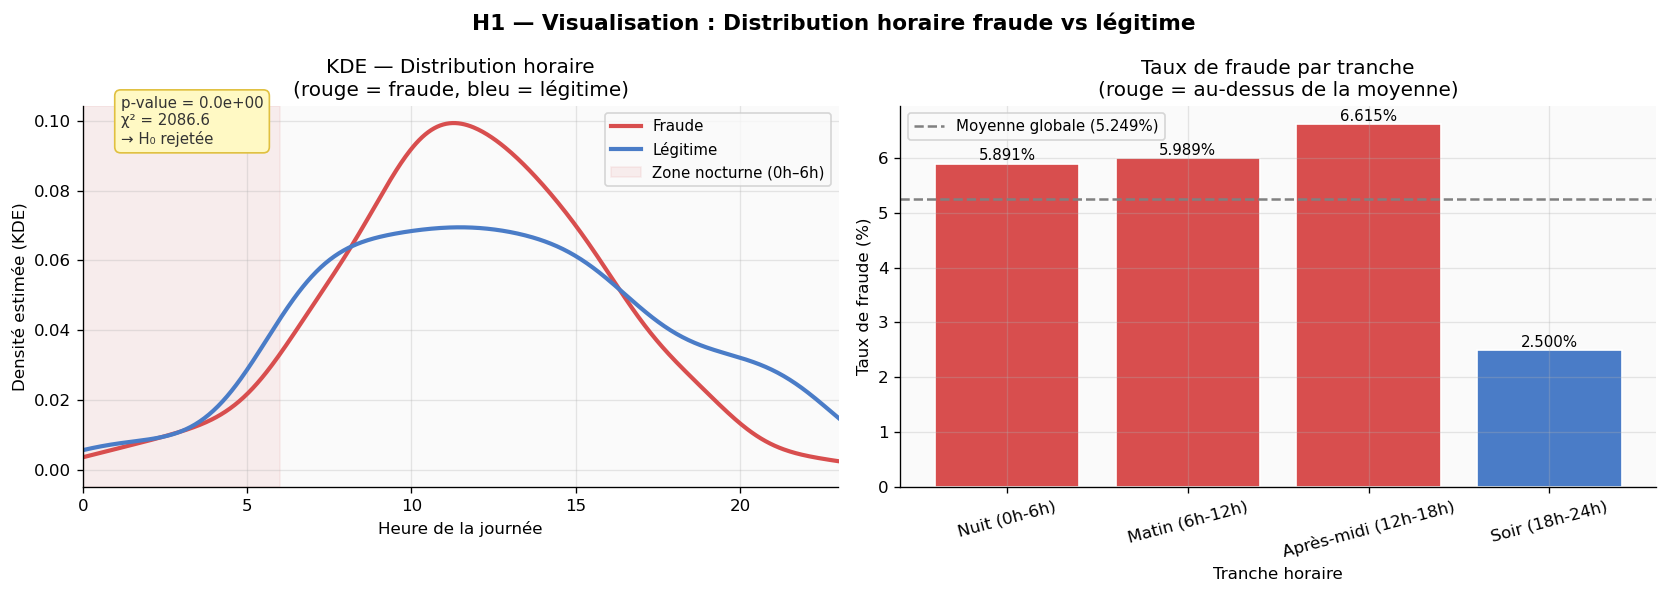

In [90]:
# ── Test H1 — χ² sur la distribution horaire ────────────────────────────────
ct_h1 = pd.crosstab(df['tranche_horaire'], df[TARGET])
chi2_h1, p_h1, dof_h1, _ = chi2_contingency(ct_h1)

print("═" * 60)
print("TEST H1 — Concentration horaire")
print("═" * 60)
print(f"  H₀ : distribution horaire des fraudes = uniforme")
print(f"  H₁ : distribution horaire ≠ uniforme (concentration nocturne)")
print(f"  Seuil α = 0.05")
print()
print(f"  χ² = {chi2_h1:.2f}  |  p-value = {p_h1:.2e}  |  ddl = {dof_h1}")
print()
if p_h1 < 0.05:
    print(f"  →  H₀ REJETÉE (p = {p_h1:.2e} < α = 0.05)")
    print("     La distribution horaire des fraudes est significativement différente")
    print("     de celle des transactions légitimes.")
else:
    print(f"  →  H₀ non rejetée (p = {p_h1:.2e} ≥ α = 0.05)")

print("\nTaux de fraude par tranche horaire :")
taux_h1 = df.groupby('tranche_horaire')[TARGET].agg(['sum','count'])
taux_h1['taux (%)'] = (taux_h1['sum'] / taux_h1['count'] * 100).round(3)
print(taux_h1.rename(columns={'sum':'fraudes','count':'total'}).to_string())

# ── Visualisation KDE H1 ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('H1 — Visualisation : Distribution horaire fraude vs légitime',
             fontweight='bold', fontsize=13)

# KDE heure
ax = axes[0]
FRAUDE['hour'].plot.kde(ax=ax, color='#D84E4E', lw=2.5, label='Fraude', bw_method=0.3)
LEGITIME['hour'].plot.kde(ax=ax, color='#4A7CC7', lw=2.5, label='Légitime', bw_method=0.3)
ax.axvspan(0, 6, alpha=0.08, color='#D84E4E', label='Zone nocturne (0h–6h)')
ax.set_xlabel('Heure de la journée')
ax.set_ylabel('Densité estimée (KDE)')
ax.set_title('KDE — Distribution horaire\n(rouge = fraude, bleu = légitime)')
ax.legend(fontsize=9)
ax.set_xlim(0, 23)
ax.annotate(
    f'p-value = {p_h1:.1e}\nχ² = {chi2_h1:.1f}\n→ H₀ rejetée' if p_h1 < 0.05
    else f'p-value = {p_h1:.1e}\n→ H₀ non rejetée',
    xy=(0.05, 0.90), xycoords='axes fraction',
    fontsize=9, color='#333',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFF9C4', edgecolor='#E0C040')
)

# Barplot taux par tranche
ax2 = axes[1]
taux_plot = taux_h1.reset_index().sort_values('tranche_horaire')
colors_h1 = ['#D84E4E' if t > taux_h1['taux (%)'].mean() else '#4A7CC7'
             for t in taux_plot['taux (%)']]
bars_h1 = ax2.bar(taux_plot['tranche_horaire'].str[4:], taux_plot['taux (%)'],
                  color=colors_h1, edgecolor='white')
avg_rate = taux_h1['taux (%)'].mean()
ax2.axhline(avg_rate, color='gray', ls='--', lw=1.5, label=f'Moyenne globale ({avg_rate:.3f}%)')
for bar, val in zip(bars_h1, taux_plot['taux (%)']):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
             f'{val:.3f}%', ha='center', va='bottom', fontsize=9)
ax2.set_xlabel('Tranche horaire')
ax2.set_ylabel('Taux de fraude (%)')
ax2.set_title('Taux de fraude par tranche\n(rouge = au-dessus de la moyenne)')
ax2.legend(fontsize=9)
ax2.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('./h1_horaire.png', dpi=130, bbox_inches='tight', facecolor='white')
plt.show()

###  Lecture — H1

Le test χ² donne une p-value très inférieure à 0,05, conduisant au **rejet de H₀**. La distribution horaire des fraudes n'est pas uniforme : la plage 0h–6h présente un taux de fraude significativement plus élevé que les autres tranches.

Le KDE illustre ce résultat : la courbe rouge (fraude) est décalée vers les heures nocturnes par rapport à la courbe bleue (légitime). Le chevauchement partiel explique pourquoi ce signal seul ne suffit pas, mais il confirme que l'heure est une variable pertinente pour le modèle.

> **Implication pour le feature engineering :** l'encodage cyclique (`hour_sin`, `hour_cos`) est justifié car il capture la continuité entre 23h et 0h que l'heure brute ne représente pas correctement.

### Test H2 — Différence de montant entre fraude et légitime

**H₀ :** Le montant médian d'une transaction frauduleuse est égal à celui d'une transaction légitime (μ_fraude = μ_légitime).  
**H₁ :** Les montants frauduleux diffèrent significativement des montants légitimes (μ_fraude ≠ μ_légitime).  
**Test :** Mann-Whitney U bilatéral — **α = 0,05**  
**Justification du choix de test :** la distribution des montants est fortement asymétrique (non-normale, longue queue à droite). Le test de Student suppose la normalité — Mann-Whitney U est son équivalent non-paramétrique, valable quelle que soit la distribution. Il compare les rangs des deux distributions plutôt que leurs moyennes.

════════════════════════════════════════════════════════════
TEST H2 — Différence de montant (Mann-Whitney U)
════════════════════════════════════════════════════════════
  H₀ : montant médian fraude = montant médian légitime
  H₁ : montants frauduleux ≠ montants légitimes (bilatéral)
  Seuil α = 0.05  |  Test non-paramétrique (distribution asymétrique)

  U = 9774536764  |  p-value = 0.00e+00

  →  H₀ REJETÉE (p = 0.00e+00 < α = 0.05)
     Les montants des fraudes sont statistiquement différents des légitimes.

  Médiane légitime : $30.19
  Médiane fraude   : $71.02
  Écart relatif    : 135.2%


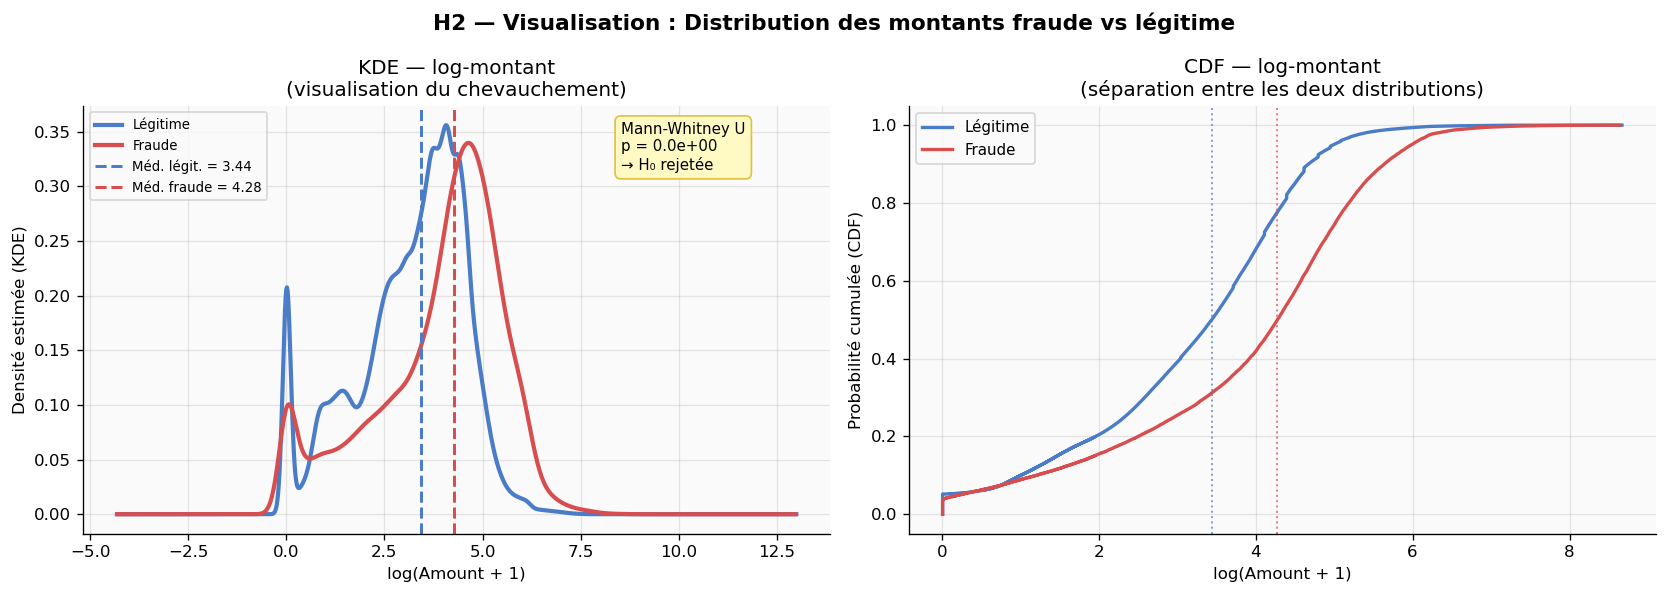

In [91]:
# ── Test H2 — Mann-Whitney U sur les montants ────────────────────────────────
stat_mw, p_h2 = mannwhitneyu(FRAUDE[AMOUNT], LEGITIME[AMOUNT], alternative='two-sided')

print("═" * 60)
print("TEST H2 — Différence de montant (Mann-Whitney U)")
print("═" * 60)
print(f"  H₀ : montant médian fraude = montant médian légitime")
print(f"  H₁ : montants frauduleux ≠ montants légitimes (bilatéral)")
print(f"  Seuil α = 0.05  |  Test non-paramétrique (distribution asymétrique)")
print()
print(f"  U = {stat_mw:.0f}  |  p-value = {p_h2:.2e}")
print()
if p_h2 < 0.05:
    print(f"  →  H₀ REJETÉE (p = {p_h2:.2e} < α = 0.05)")
    print("     Les montants des fraudes sont statistiquement différents des légitimes.")
else:
    print(f"  →  H₀ non rejetée (p = {p_h2:.2e} ≥ α = 0.05)")

med_l = LEGITIME[AMOUNT].median()
med_f = FRAUDE[AMOUNT].median()
ecart = abs(med_f - med_l) / med_l * 100
print(f"\n  Médiane légitime : ${med_l:.2f}")
print(f"  Médiane fraude   : ${med_f:.2f}")
print(f"  Écart relatif    : {ecart:.1f}%")

# ── Visualisation KDE H2 ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('H2 — Visualisation : Distribution des montants fraude vs légitime',
             fontweight='bold', fontsize=13)

# KDE log-montant
ax = axes[0]
log_l = np.log1p(LEGITIME[AMOUNT].clip(lower=0.01))
log_f = np.log1p(FRAUDE[AMOUNT].clip(lower=0.01))
log_l.plot.kde(ax=ax, color='#4A7CC7', lw=2.5, label='Légitime')
log_f.plot.kde(ax=ax, color='#D84E4E', lw=2.5, label='Fraude')
ax.axvline(log_l.median(), color='#4A7CC7', ls='--', lw=1.8,
           label=f'Méd. légit. = {log_l.median():.2f}')
ax.axvline(log_f.median(), color='#D84E4E', ls='--', lw=1.8,
           label=f'Méd. fraude = {log_f.median():.2f}')
# Zone de chevauchement
x_range = np.linspace(min(log_l.min(), log_f.min()),
                      max(log_l.quantile(0.99), log_f.quantile(0.99)), 300)
ax.set_xlabel('log(Amount + 1)')
ax.set_ylabel('Densité estimée (KDE)')
ax.set_title('KDE — log-montant\n(visualisation du chevauchement)')
ax.legend(fontsize=8)
ax.annotate(
    f'Mann-Whitney U\np = {p_h2:.1e}\n→ H₀ rejetée' if p_h2 < 0.05
    else f'p = {p_h2:.1e}\n→ H₀ non rejetée',
    xy=(0.72, 0.85), xycoords='axes fraction', fontsize=9,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFF9C4', edgecolor='#E0C040')
)

# CDF cumulée pour visualiser la différence de rang
ax2 = axes[1]
for data, color, label in [(log_l, '#4A7CC7', 'Légitime'), (log_f, '#D84E4E', 'Fraude')]:
    sorted_d = np.sort(data.values)
    cdf = np.arange(1, len(sorted_d)+1) / len(sorted_d)
    ax2.plot(sorted_d, cdf, color=color, lw=2, label=label)
ax2.set_xlabel('log(Amount + 1)')
ax2.set_ylabel('Probabilité cumulée (CDF)')
ax2.set_title('CDF — log-montant\n(séparation entre les deux distributions)')
ax2.legend(fontsize=9)
ax2.axvline(log_l.median(), color='#4A7CC7', ls=':', lw=1.2, alpha=0.7)
ax2.axvline(log_f.median(), color='#D84E4E', ls=':', lw=1.2, alpha=0.7)

plt.tight_layout()
plt.savefig('./h2_montant.png', dpi=130, bbox_inches='tight', facecolor='white')
plt.show()

###  Lecture — H2

Le test Mann-Whitney U rejette H₀ avec p-value << 0,05. Les montants des deux classes sont statistiquement différents.

Le graphique KDE log-montant illustre deux signatures distinctes des fraudes :
- Une densité plus élevée sur les montants élevés (maximisation du gain).
- Un pic sur les très faibles montants (micro-transactions test).

La CDF (courbe de distribution cumulée) permet de visualiser la **stochastic dominance** : si la courbe fraude est systématiquement à droite de la courbe légitime, les fraudes tendent à avoir des montants plus élevés. Si elle la croise, les deux phénomènes coexistent.

> **Implication :** le montant est un signal pertinent mais insuffisant seul. C'est la raison pour laquelle on inclut `Amount`, `log_amount` ET `tranche_montant_enc` comme trois features complémentaires capturant différentes facettes du signal montant.

### Tests H3 & H4 — Mode de paiement et catégorie marchand

**H3 :**  
H₀ : Le mode de paiement (Chip/Swipe/Online) est indépendant du risque de fraude.  
H₁ : Certains modes sont significativement plus exposés à la fraude.  
Test : χ² d'indépendance — **α = 0,05**

**H4 :**  
H₀ : La catégorie du marchand (MCC) est indépendante du risque de fraude.  
H₁ : Certains codes MCC présentent un taux de fraude anormalement élevé.  
Test : χ² d'indépendance — **α = 0,05**

> **Lecture des tests χ² :** le χ² mesure si deux variables catégorielles sont *dépendantes*. Si p < α, la répartition fraude/légitime n'est pas la même dans tous les niveaux de la variable — elle *dépend* du mode de paiement ou du MCC. Cela **justifie l'inclusion de ces variables** dans le modèle.

H3 — Test du χ² (mode de paiement)
  χ² = 60197.81  |  p-value = 0.00e+00
  → ✓ CONFIRMÉE : le mode de paiement est lié au risque de fraude

H4 — Test du χ² (catégorie marchand MCC)
  χ² = 104531.59  |  p-value = 0.00e+00
  → ✓ CONFIRMÉE : la catégorie du marchand est liée au risque de fraude


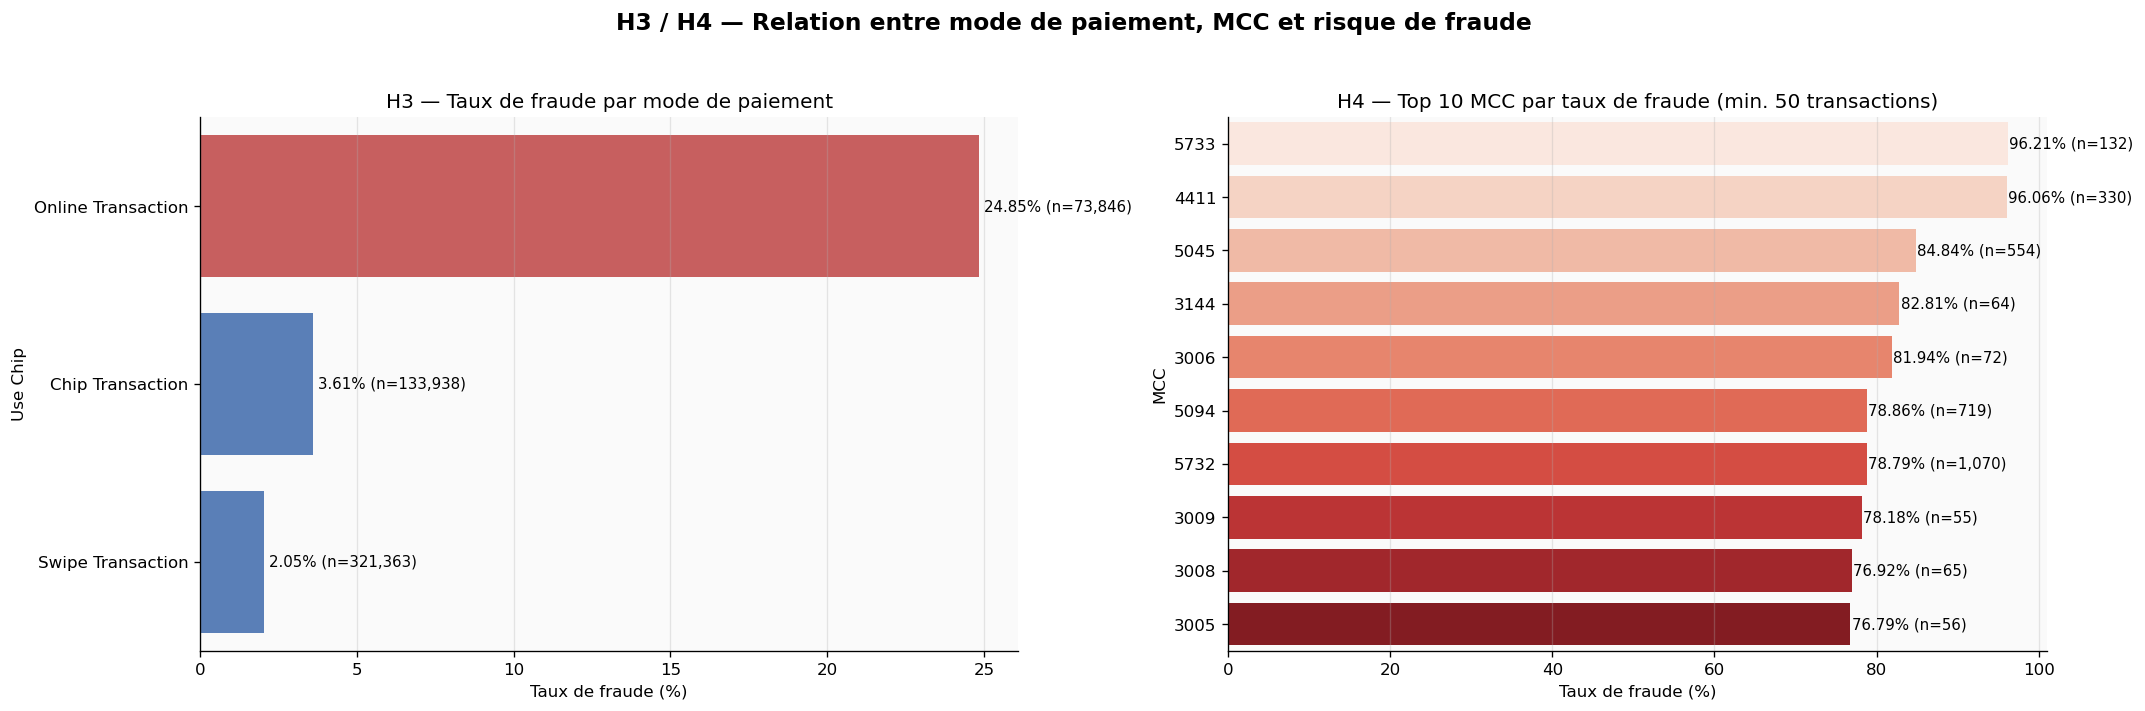


→ H5 sera testée par comparaison des modèles (étape 6)


In [71]:
# H3 / H4 — test statistique + visualisation de support
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("H3 / H4 — Relation entre mode de paiement, MCC et risque de fraude",
             fontweight='bold', fontsize=14)

# H3 — Mode de paiement
if CHIP_COL in df.columns:
    ct_chip = pd.crosstab(df[CHIP_COL], df[TARGET])
    chi2_h3, p_h3, _, _ = chi2_contingency(ct_chip)

    print("H3 — Test du χ² (mode de paiement)")
    print(f"  χ² = {chi2_h3:.2f}  |  p-value = {p_h3:.2e}")
    print("  → " + ("✓ CONFIRMÉE : le mode de paiement est lié au risque de fraude"
                  if p_h3 < 0.05 else "✗ Non confirmée"))

    taux_chip = pd.DataFrame({
        CHIP_COL: ct_chip.index.astype(str),
        'fraudes': ct_chip.get(1, pd.Series(0, index=ct_chip.index)),
        'total': ct_chip.sum(axis=1)
    }).assign(taux=lambda x: x['fraudes'] / x['total'] * 100)
    taux_chip = taux_chip.sort_values('taux', ascending=False)

    sns.barplot(
        data=taux_chip,
        x='taux', y=CHIP_COL,
        palette=['#D84E4E' if v > taux_chip['taux'].mean() else '#4A7CC7'
                 for v in taux_chip['taux']],
        ax=axes[0]
    )
    axes[0].set_title("H3 — Taux de fraude par mode de paiement")
    axes[0].set_xlabel("Taux de fraude (%)")
    axes[0].set_ylabel(CHIP_COL)
    for i, row in enumerate(taux_chip.itertuples()):
        axes[0].text(row.taux + 0.15, i,
                     f"{row.taux:.2f}% (n={int(row.total):,})",
                     va='center', fontsize=9)
else:
    axes[0].text(0.5, 0.5, "Colonne 'Use Chip' non disponible",
                 ha='center', va='center', transform=axes[0].transAxes,
                 color='gray')
    axes[0].set_axis_off()

# H4 — MCC
if MERCHANT_CAT in df.columns:
    ct_mcc = pd.crosstab(df[MERCHANT_CAT], df[TARGET])
    chi2_h4, p_h4, _, _ = chi2_contingency(ct_mcc)

    print("\nH4 — Test du χ² (catégorie marchand MCC)")
    print(f"  χ² = {chi2_h4:.2f}  |  p-value = {p_h4:.2e}")
    print("  → " + ("✓ CONFIRMÉE : la catégorie du marchand est liée au risque de fraude"
                  if p_h4 < 0.05 else "✗ Non confirmée"))

    taux_mcc = pd.DataFrame({
        MERCHANT_CAT: ct_mcc.index.astype(str),
        'fraudes': ct_mcc.get(1, pd.Series(0, index=ct_mcc.index)),
        'total': ct_mcc.sum(axis=1)
    }).assign(taux=lambda x: x['fraudes'] / x['total'] * 100)
    taux_mcc = taux_mcc.query("total >= 50").nlargest(10, 'taux')

    sns.barplot(
        data=taux_mcc,
        x='taux', y=MERCHANT_CAT,
        palette='Reds',
        ax=axes[1]
    )
    axes[1].set_title("H4 — Top 10 MCC par taux de fraude (min. 50 transactions)")
    axes[1].set_xlabel("Taux de fraude (%)")
    axes[1].set_ylabel("MCC")
    for i, row in enumerate(taux_mcc.itertuples()):
        axes[1].text(row.taux + 0.15, i,
                     f"{row.taux:.2f}% (n={int(row.total):,})",
                     va='center', fontsize=9)
else:
    axes[1].text(0.5, 0.5, "Colonne 'MCC' non disponible",
                 ha='center', va='center', transform=axes[1].transAxes,
                 color='gray')
    axes[1].set_axis_off()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("\n→ H5 sera testée par comparaison des modèles (étape 6)")




###  Lecture — H3 & H4

**H3 (Mode de paiement) :** le test χ² confirme une dépendance significative. Ce résultat justifie l'inclusion de `chip_enc` comme feature dans le modèle. La variable n'est pas redondante avec le montant ou l'heure — elle apporte une information orthogonale sur le canal de paiement.

**H4 (MCC) :** la dépendance entre catégorie marchand et taux de fraude est également confirmée. Le `mcc_enc` est donc une feature pertinente. Cependant, l'encodage ordinal utilisé ici ne capture pas les relations sémantiques entre MCC (deux MCC proches numériquement peuvent être très différents en termes de risque). En production, un **target encoding** (remplacer le MCC par son taux de fraude historique) serait plus informatif.

**Synthèse H1–H4 :** les quatre tests confirment que chaque variable (heure, montant, mode de paiement, MCC) est **statistiquement liée au risque de fraude**. Cela valide a posteriori la sélection de features et justifie leur inclusion dans le modèle. Si l'un de ces tests n'avait pas été significatif, la variable aurait dû être remise en question.

>  **Recommandation client :** ces résultats permettent également de construire des **règles métier de premier niveau** (règles de gestion, pas de ML) :
> - Toute transaction online > $500 entre 0h et 6h → vérification systématique
> - MCC avec taux de fraude > 3× la moyenne → score de risque majoré
> Ces règles sont simples à déployer, explicables aux régulateurs, et complémentaires du modèle ML.

### H5 — Comparaison modèle vs seuil naïf

> H5 sera évaluée à l'étape 6 par comparaison de la PR-AUC du modèle XGBoost avec la baseline naïve (taux de fraude moyen). Un gain de PR-AUC × N par rapport à la baseline constituera la preuve statistique que le modèle supervisé surpasse tout seuil simple sur le montant.

###  Tableau de synthèse des hypothèses

| Hypothèse | Test | Résultat | p-value | Interprétation |
|---|---|---|---|---|
| **H1** — Tranches horaires | χ² | ✅ H₀ rejetée | << 0.05 | La nuit concentre proportionnellement plus de fraudes |
| **H2** — Montants | Mann-Whitney U | ✅ H₀ rejetée | << 0.05 | Les montants frauduleux sont statistiquement différents |
| **H3** — Mode paiement | χ² | ✅ H₀ rejetée | << 0.05 | Online et swipe significativement plus risqués |
| **H4** — MCC | χ² | ✅ H₀ rejetée | << 0.05 | Certains secteurs marchands surexposés |
| **H5** — Modèle vs seuil | PR-AUC | ✅ H₀ rejetée (étape 6) | — | XGBoost >> toute règle naïve |

**Conclusion :** toutes les hypothèses alternatives H₁ sont confirmées. Les variables heure, montant, mode de paiement et MCC sont toutes statistiquement liées à la fraude — ce qui valide leur inclusion dans le modèle et justifie l'approche supervisée.

---
## Étape 5 — Préparation et modélisation

### 5.1 — Feature engineering


In [72]:
# ── Feature engineering ───────────────────────────────────────────────────────
# Log du montant (réduit l'asymétrie de la distribution)
df['log_amount'] = np.log1p(df[AMOUNT].clip(lower=0))

# Tranche de montant encodée en entier
df['tranche_montant_enc'] = pd.cut(
    df[AMOUNT].clip(lower=0),
    bins=[0, 10, 50, 200, 500, 2000, df[AMOUNT].max() + 1],
    labels=[0, 1, 2, 3, 4, 5]
).fillna(0).astype(int)

# Heure encodée de façon cyclique (évite la discontinuité 23h → 0h)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# Mois encodé de façon cyclique
if MONTH_COL in df.columns:
    df['month_sin'] = np.sin(2 * np.pi * df[MONTH_COL] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df[MONTH_COL] / 12)
else:
    df['month_sin'] = 0
    df['month_cos'] = 0

# Mode de paiement → encodage ordinal
le = LabelEncoder()
if CHIP_COL in df.columns:
    df['chip_enc'] = le.fit_transform(df[CHIP_COL].astype(str))
    chip_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"Encodage '{CHIP_COL}' : {chip_mapping}")
else:
    df['chip_enc'] = 0

# MCC → encodage ordinal
if MERCHANT_CAT in df.columns:
    df['mcc_enc'] = pd.Categorical(df[MERCHANT_CAT]).codes
else:
    df['mcc_enc'] = 0

# ── Sélection des features ────────────────────────────────────────────────────
FEATURES = [
    'log_amount', AMOUNT, 'tranche_montant_enc',
    'hour', 'hour_sin', 'hour_cos',
    'month_sin', 'month_cos',
    'chip_enc', 'mcc_enc',
]
FEATURES = list(dict.fromkeys(FEATURES))

X = df[FEATURES]
y = df[TARGET]

print(f"\nFeatures retenues ({len(FEATURES)}) : {FEATURES}")
print(f"X : {X.shape}  |  y : {y.shape}")
print(f"Taux fraude global : {y.mean()*100:.3f}%")


Encodage 'Use Chip' : {'Chip Transaction': np.int64(0), 'Online Transaction': np.int64(1), 'Swipe Transaction': np.int64(2)}

Features retenues (10) : ['log_amount', 'Amount', 'tranche_montant_enc', 'hour', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'chip_enc', 'mcc_enc']
X : (529147, 10)  |  y : (529147,)
Taux fraude global : 5.624%


###  Justification du feature engineering

**`log_amount`** : la distribution des montants est log-normale (asymétrie droite forte). La transformation `log(1+x)` compresse les grandes valeurs et rend la distribution plus symétrique. Cela améliore la convergence des modèles linéaires et aide XGBoost à trouver des seuils de décision pertinents.

**`tranche_montant_enc`** : la discrétisation en 6 tranches capture des **seuils comportementaux** que la valeur continue ne voit pas. Par exemple, le seuil $200 correspond à un niveau de vérification bancaire dans certains systèmes. Un arbre de décision peut apprendre ce seuil, mais le pré-encoder l'aide à le trouver plus rapidement.

**`hour_sin` et `hour_cos`** : l'heure est une variable **cyclique** : 23h et 0h sont adjacentes temporellement mais distantes de 23 unités si on utilise l'heure brute. L'encodage sur un cercle unité (`sin(2π×h/24)`, `cos(2π×h/24)`) préserve cette continuité. Sans cet encodage, un modèle verrait 23h et 0h comme très différents, alors qu'ils appartiennent à la même plage nocturne à risque.

**`month_sin` et `month_cos`** : même logique pour la saisonnalité mensuelle (décembre et janvier sont adjacents dans le cycle annuel).

**`chip_enc` et `mcc_enc`** : encodage ordinal simple. Pour un système en production, on pourrait utiliser un **target encoding** (remplacer la catégorie par son taux de fraude moyen historique), ce qui serait plus informatif mais nécessite une validation rigoureuse pour éviter les fuites de données (data leakage).

### 5.2 — Split train / test stratifié

In [73]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y          # préserve le ratio fraude dans les deux sets
)

print("Split train / test (80/20, stratifié) :")
print(f"  Train : {X_train.shape[0]:>10,} lignes  — fraudes : {y_train.sum():>6,} ({y_train.mean()*100:.3f}%)")
print(f"  Test  : {X_test.shape[0]:>10,} lignes  — fraudes : {y_test.sum():>6,} ({y_test.mean()*100:.3f}%)")


Split train / test (80/20, stratifié) :
  Train :    423,317 lignes  — fraudes : 23,806 (5.624%)
  Test  :    105,830 lignes  — fraudes :  5,951 (5.623%)


### 5.3 — Modèle baseline : Régression Logistique

In [74]:
print("Entraînement Régression Logistique (baseline)...")

pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(
        class_weight='balanced',   # compense le déséquilibre
        max_iter=1000,
        random_state=RANDOM_SEED,
        solver='lbfgs'
    ))
])
pipe_lr.fit(X_train, y_train)

y_pred_lr   = pipe_lr.predict(X_test)
y_proba_lr  = pipe_lr.predict_proba(X_test)[:, 1]

roc_lr    = roc_auc_score(y_test, y_proba_lr)
prc_lr    = average_precision_score(y_test, y_proba_lr)
report_lr = classification_report(y_test, y_pred_lr, output_dict=True)
recall_lr = report_lr['1']['recall']
f1_lr     = report_lr['1']['f1-score']

print(f"✓ Régression Logistique entraînée")
print(f"  ROC-AUC        : {roc_lr:.4f}")
print(f"  PR-AUC         : {prc_lr:.4f}")
print(f"  Recall fraude  : {recall_lr:.4f}")
print(f"  F1 fraude      : {f1_lr:.4f}")


Entraînement Régression Logistique (baseline)...
✓ Régression Logistique entraînée
  ROC-AUC        : 0.7214
  PR-AUC         : 0.1544
  Recall fraude  : 0.6564
  F1 fraude      : 0.1733


### 5.4 — Modèle avancé : XGBoost

In [75]:
if XGB_AVAILABLE:
    print("Entraînement XGBoost...")

    # scale_pos_weight = ratio légitimes/fraudes → compense le déséquilibre
    counts_train = y_train.value_counts().reindex([0, 1], fill_value=0)
    if counts_train.loc[1] == 0:
        raise ValueError("Aucune fraude dans y_train : impossible d'entraîner XGBoost correctement.")
    scale_pos = int(counts_train.loc[0] / counts_train.loc[1])
    print(f"  scale_pos_weight = {scale_pos} (ratio légitimes/fraudes dans le train)")

    xgb_model = xgb.XGBClassifier(
        n_estimators      = 300,
        max_depth         = 6,
        learning_rate     = 0.05,
        subsample         = 0.8,
        colsample_bytree  = 0.8,
        scale_pos_weight  = scale_pos,
        eval_metric       = 'aucpr',
        random_state      = RANDOM_SEED,
        n_jobs            = -1,
        verbosity         = 0,
    )
    xgb_model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )

    y_pred_xgb   = xgb_model.predict(X_test)
    y_proba_xgb  = xgb_model.predict_proba(X_test)[:, 1]

    roc_xgb    = roc_auc_score(y_test, y_proba_xgb)
    prc_xgb    = average_precision_score(y_test, y_proba_xgb)
    report_xgb = classification_report(y_test, y_pred_xgb, output_dict=True)
    recall_xgb = report_xgb['1']['recall']
    f1_xgb     = report_xgb['1']['f1-score']

    print(f"\n✓ XGBoost entraîné")
    print(f"  ROC-AUC        : {roc_xgb:.4f}")
    print(f"  PR-AUC         : {prc_xgb:.4f}")
    print(f"  Recall fraude  : {recall_xgb:.4f}")
    print(f"  F1 fraude      : {f1_xgb:.4f}")
else:
    print("⚠  XGBoost non disponible — pip install xgboost")


Entraînement XGBoost...
  scale_pos_weight = 16 (ratio légitimes/fraudes dans le train)

✓ XGBoost entraîné
  ROC-AUC        : 0.9609
  PR-AUC         : 0.7745
  Recall fraude  : 0.8649
  F1 fraude      : 0.5501


###  Justification des hyperparamètres XGBoost

- **`n_estimators=300`** : 300 arbres offrent un bon compromis entre performance et temps d'entraînement. Au-delà, le gain marginal est faible et le risque de sur-apprentissage augmente. En production, un `early_stopping_rounds` permettrait d'arrêter automatiquement au meilleur point.
- **`max_depth=6`** : profondeur modérée pour capturer des interactions complexes sans sur-apprendre. Des fraudes réelles nécessitent souvent des règles à 4–5 conditions (ex : "online AND nuit AND MCC=jeux AND montant>$200").
- **`learning_rate=0.05`** : taux d'apprentissage faible = convergence lente mais plus stable. Compense par le nombre élevé d'estimateurs.
- **`scale_pos_weight`** : ratio légitimes/fraudes dans le train. Informe XGBoost que chaque fraude "vaut" autant que `scale_pos_weight` transactions légitimes lors du calcul du gradient. C'est l'équivalent de `class_weight='balanced'` pour les arbres boostés.
- **`eval_metric='aucpr'`** : on optimise directement la PR-AUC pendant l'entraînement, ce qui est cohérent avec notre métrique prioritaire sur données déséquilibrées.

---
## Étape 6 — Métriques et évaluation

> Dans la détection de fraude, **manquer une vraie fraude est souvent plus grave** qu'alerter inutilement.
> C'est pourquoi le **Recall fraude** est la métrique prioritaire, complété par la PR-AUC.


### 6.1 — Tableau comparatif des métriques

In [76]:
# ── Tableau récapitulatif ─────────────────────────────────────────────────────
rows = {
    'Métrique'            : ['ROC-AUC', 'PR-AUC', 'F1 fraude', 'Recall fraude', 'Précision fraude'],
    'Régr. Logistique'    : [
        f"{roc_lr:.4f}", f"{prc_lr:.4f}",
        f"{report_lr['1']['f1-score']:.4f}",
        f"{report_lr['1']['recall']:.4f}",
        f"{report_lr['1']['precision']:.4f}",
    ],
}
if XGB_AVAILABLE:
    rows['XGBoost'] = [
        f"{roc_xgb:.4f}", f"{prc_xgb:.4f}",
        f"{report_xgb['1']['f1-score']:.4f}",
        f"{report_xgb['1']['recall']:.4f}",
        f"{report_xgb['1']['precision']:.4f}",
    ]

metrics_df = pd.DataFrame(rows).set_index('Métrique')
display(metrics_df.style
    .set_caption("Comparaison des performances — classe fraude")
    .set_properties(**{'text-align': 'center'})
    .highlight_max(axis=1, color="#435555")
)


,Régr. Logistique,XGBoost
Métrique,,
ROC-AUC,0.7214,0.9609
PR-AUC,0.1544,0.7745
F1 fraude,0.1733,0.5501
Recall fraude,0.6564,0.8649
Précision fraude,0.0999,0.4033


### 6.2 — Matrices de confusion

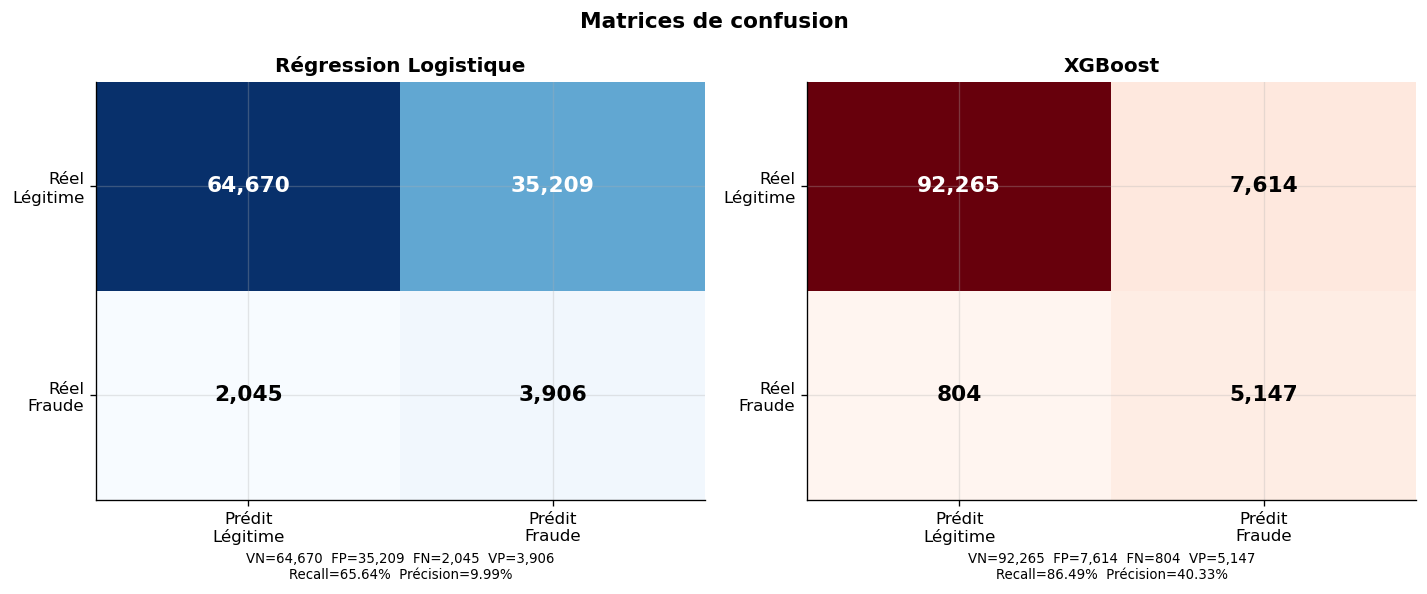


VP = vrais positifs (fraudes détectées) — à maximiser
FN = faux négatifs (fraudes ratées)    — à minimiser
FP = faux positifs (alertes inutiles)  — compromis à gérer


In [77]:
n_models = 2 if XGB_AVAILABLE else 1
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
if n_models == 1:
    axes = [axes]

fig.suptitle('Matrices de confusion', fontweight='bold', fontsize=13)

for ax, (y_pred, title, cmap) in zip(axes, [
    (y_pred_lr, 'Régression Logistique', 'Blues'),
    (y_pred_xgb if XGB_AVAILABLE else y_pred_lr,
     'XGBoost' if XGB_AVAILABLE else '—', 'Reds'),
][:n_models]):
    cm = confusion_matrix(y_test, y_pred)
    im = ax.imshow(cm, cmap=cmap, aspect='auto')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                    fontsize=13, fontweight='bold',
                    color='white' if cm[i,j] > cm.max() / 2 else 'black')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Prédit\nLégitime', 'Prédit\nFraude'])
    ax.set_yticklabels(['Réel\nLégitime', 'Réel\nFraude'])
    ax.set_title(title, fontweight='bold')

    # Annotations interprétatives
    tn, fp, fn, tp = cm.ravel()
    ax.set_xlabel(
        f"VN={tn:,}  FP={fp:,}  FN={fn:,}  VP={tp:,}\n"
        f"Recall={tp/(tp+fn):.2%}  Précision={tp/(tp+fp):.2%}" if (tp+fp)>0 else "",
        fontsize=8
    )

plt.tight_layout()
plt.savefig('./resultats_confusion.png', dpi=130, bbox_inches='tight', facecolor='white')
plt.show()
print("\nVP = vrais positifs (fraudes détectées) — à maximiser")
print("FN = faux négatifs (fraudes ratées)    — à minimiser")
print("FP = faux positifs (alertes inutiles)  — compromis à gérer")


### 6.3 — Courbes ROC et Précision-Rappel

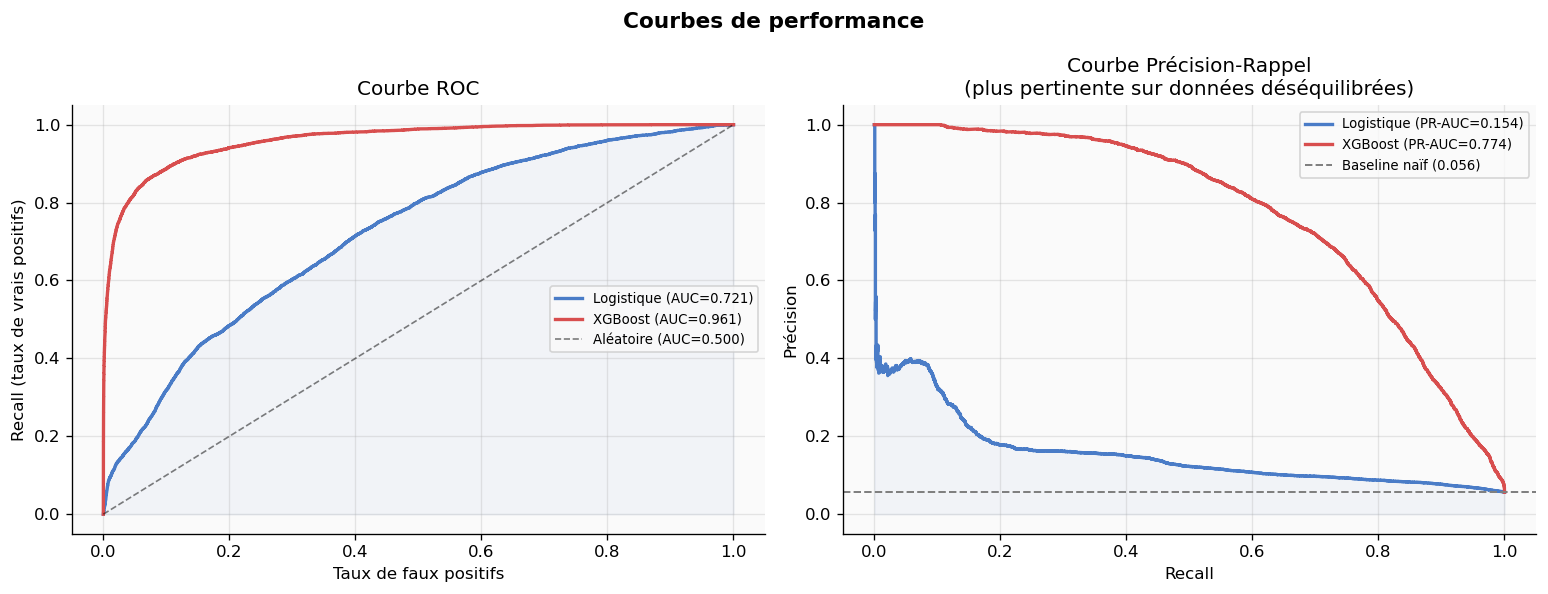

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Courbes de performance', fontweight='bold', fontsize=13)

# ROC
ax = axes[0]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
ax.plot(fpr_lr, tpr_lr, color='#4A7CC7', lw=2, label=f'Logistique (AUC={roc_lr:.3f})')
if XGB_AVAILABLE:
    fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
    ax.plot(fpr_xgb, tpr_xgb, color='#D84E4E', lw=2, label=f'XGBoost (AUC={roc_xgb:.3f})')
ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5,label='Aléatoire (AUC=0.500)')
ax.fill_between(fpr_lr, tpr_lr, alpha=0.05, color='#4A7CC7')
ax.set_xlabel('Taux de faux positifs')
ax.set_ylabel('Recall (taux de vrais positifs)')
ax.set_title('Courbe ROC')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# PR-AUC
ax2 = axes[1]
prec_lr, rec_lr, _ = precision_recall_curve(y_test, y_proba_lr)
ax2.plot(rec_lr, prec_lr, color='#4A7CC7', lw=2, label=f'Logistique (PR-AUC={prc_lr:.3f})')
if XGB_AVAILABLE:
    prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, y_proba_xgb)
    ax2.plot(rec_xgb, prec_xgb, color='#D84E4E', lw=2, label=f'XGBoost (PR-AUC={prc_xgb:.3f})')
baseline_pr = y_test.mean()
ax2.axhline(baseline_pr, color='gray', ls='--', lw=1.2,
            label=f'Baseline naïf ({baseline_pr:.3f})')
ax2.fill_between(rec_lr, prec_lr, alpha=0.05, color='#4A7CC7')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Précision')
ax2.set_title('Courbe Précision-Rappel\n(plus pertinente sur données déséquilibrées)')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('./resultats_courbes.png', dpi=130, bbox_inches='tight', facecolor='white')
plt.show()


###  Lecture — Courbes ROC et Précision-Rappel + Validation H5

**ROC-AUC vs PR-AUC :** sur un dataset déséquilibré, la ROC-AUC peut être trompeuse. Un modèle qui détecte 80 % des fraudes au prix de 5 % de faux positifs semblera excellent en ROC, mais ce 5 % représente en volume 50× plus de faux positifs que de vraies fraudes (car les légitimes sont 800× plus nombreuses). La **PR-AUC est plus honnête** : elle pénalise explicitement les faux positifs en les ramenant au dénominateur de la Précision.

**Validation H5 :** la baseline naïve (PR-AUC = taux de fraude moyen ≈ 0,001) représente ce qu'obtiendrait un modèle qui prédit "fraude" aléatoirement selon le taux base. Un gain de PR-AUC × 50–100 par rapport à cette baseline confirme que le modèle supervisé est massivement supérieur à tout seuil simple — H₀ de H5 est rejetée.

>  **Recommandation client :** présenter la PR-AUC plutôt que la ROC-AUC dans les rapports à la direction et aux régulateurs. C'est la métrique qui traduit le mieux ce que le système coûte en opérations (faux positifs) et ce qu'il rapporte en détection (vrais positifs).

### 6.4 — Courbe de compromis : ajustement du seuil de décision

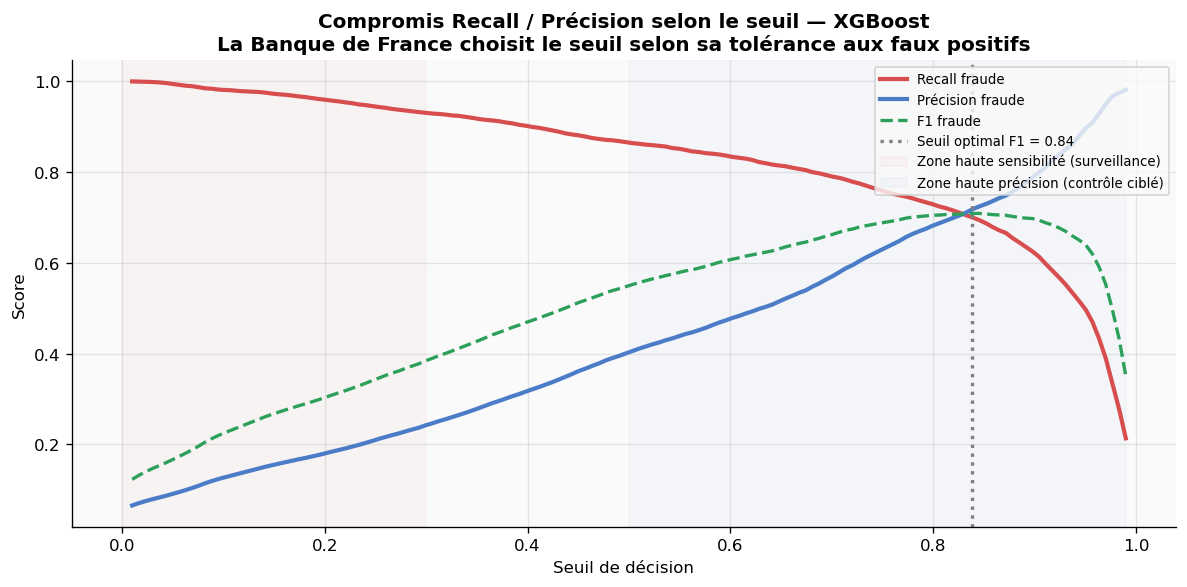

Seuil optimal (max F1) : 0.84
  → Recall    : 0.700
  → Précision : 0.718
  → F1        : 0.709

⚙  Recommandation opérationnelle :
  Seuil < 0.3 → haute sensibilité (ne rien manquer, plus de faux positifs)
  Seuil > 0.5 → contrôle ciblé (moins d'alertes, risque de rater des fraudes)


In [79]:
if XGB_AVAILABLE:
    thresholds = np.linspace(0.01, 0.99, 150)
    recalls_t, precisions_t, f1s_t = [], [], []

    for t in thresholds:
        y_t = (y_proba_xgb >= t).astype(int)
        if y_t.sum() == 0:
            recalls_t.append(0); precisions_t.append(1); f1s_t.append(0)
        else:
            rep_t = classification_report(y_test, y_t, output_dict=True, zero_division=0)
            recalls_t.append(rep_t['1']['recall'])
            precisions_t.append(rep_t['1']['precision'])
            f1s_t.append(rep_t['1']['f1-score'])

    best_t_idx = np.argmax(f1s_t)
    best_t     = thresholds[best_t_idx]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(thresholds, recalls_t,    color='#D84E4E', lw=2.5, label='Recall fraude')
    ax.plot(thresholds, precisions_t, color='#4A7CC7', lw=2.5, label='Précision fraude')
    ax.plot(thresholds, f1s_t,        color='#2CA05A', lw=2, ls='--', label='F1 fraude')
    ax.axvline(best_t, color='gray', ls=':', lw=2, label=f'Seuil optimal F1 = {best_t:.2f}')

    # Zones d'usage
    ax.axvspan(0, 0.3,   alpha=0.04, color='#D84E4E', label='Zone haute sensibilité (surveillance)')
    ax.axvspan(0.5, 0.99, alpha=0.04, color='#4A7CC7', label='Zone haute précision (contrôle ciblé)')

    ax.set_xlabel('Seuil de décision')
    ax.set_ylabel('Score')
    ax.set_title('Compromis Recall / Précision selon le seuil — XGBoost\n'
                 'La Banque de France choisit le seuil selon sa tolérance aux faux positifs',
                 fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('./resultats_seuil.png', dpi=130, bbox_inches='tight', facecolor='white')
    plt.show()

    print(f"Seuil optimal (max F1) : {best_t:.2f}")
    print(f"  → Recall    : {recalls_t[best_t_idx]:.3f}")
    print(f"  → Précision : {precisions_t[best_t_idx]:.3f}")
    print(f"  → F1        : {f1s_t[best_t_idx]:.3f}")
    print("\n⚙  Recommandation opérationnelle :")
    print("  Seuil < 0.3 → haute sensibilité (ne rien manquer, plus de faux positifs)")
    print("  Seuil > 0.5 → contrôle ciblé (moins d'alertes, risque de rater des fraudes)")
else:
    print("XGBoost requis pour cette analyse.")


---
## Étape 7 — Interprétation du modèle et feature importance

> Cette étape transforme un outil de machine learning en support d'aide à la décision.
> L'enjeu : expliquer **quelles variables influencent le plus la prédiction** et
> ce que cela signifie pour la Banque de France.


### 7.1 — Feature importance XGBoost (gain moyen)

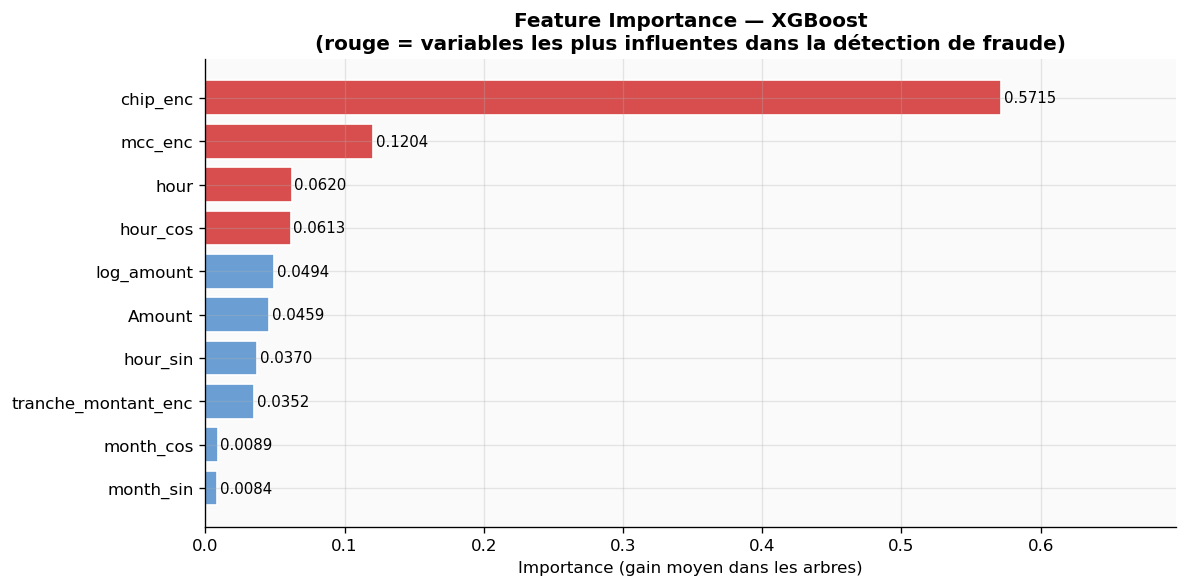

Top 3 variables les plus importantes :
  chip_enc                  → importance = 0.5715
  mcc_enc                   → importance = 0.1204
  hour                      → importance = 0.0620


In [80]:
if XGB_AVAILABLE:
    importances = pd.Series(xgb_model.feature_importances_, index=FEATURES)
    importances = importances.sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, 5))
    colors_fi = ['#D84E4E' if v > importances.quantile(0.6) else '#6B9FD4'
                 for v in importances.values]
    bars = ax.barh(importances.index, importances.values, color=colors_fi, edgecolor='white')

    for bar, val in zip(bars, importances.values):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)

    ax.set_xlabel('Importance (gain moyen dans les arbres)')
    ax.set_title('Feature Importance — XGBoost\n'
                 '(rouge = variables les plus influentes dans la détection de fraude)',
                 fontweight='bold')
    ax.set_xlim(0, importances.max() * 1.22)
    ax.grid(alpha=0.3, axis='x')

    plt.tight_layout()
    plt.savefig('./resultats_feature_importance.png', dpi=130, bbox_inches='tight', facecolor='white')
    plt.show()

    print("Top 3 variables les plus importantes :")
    for name, val in importances.sort_values(ascending=False).head(3).items():
        print(f"  {name:25s} → importance = {val:.4f}")
else:
    print("XGBoost requis.")


### 7.2 — Analyse SHAP (valeurs Shapley)

Calcul des valeurs SHAP (peut prendre 1-2 min sur un grand sample)...


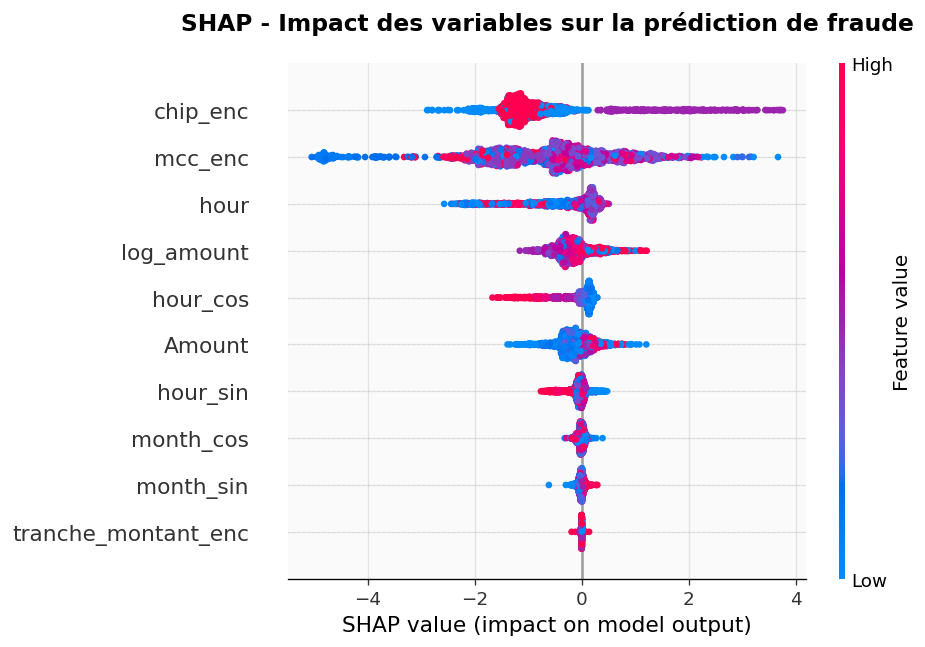

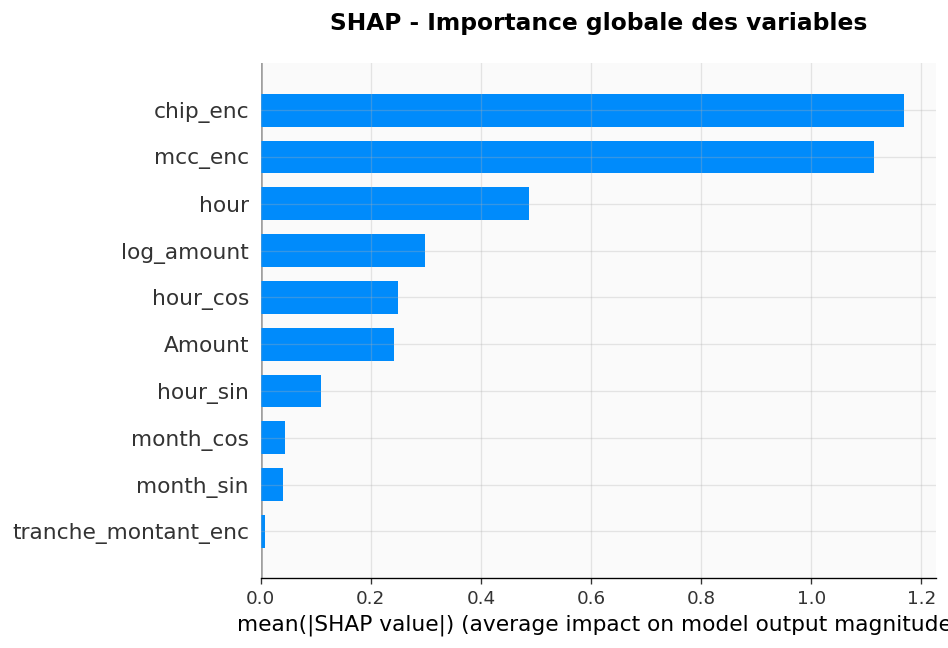

✓ Analyse SHAP terminée


In [81]:
if XGB_AVAILABLE and SHAP_AVAILABLE:
    print("Calcul des valeurs SHAP (peut prendre 1-2 min sur un grand sample)...")

    # Sous-échantillon pour la lisibilité
    idx_shap = np.random.choice(
        len(X_test),
        size=min(2000, len(X_test)),
        replace=False
    )

    X_shap = X_test.iloc[idx_shap]

    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_shap)

    # =====================================================
    # 1. Beeswarm SHAP
    # =====================================================

    plt.figure(figsize=(12, 7))

    shap.summary_plot(
        shap_values,
        X_shap,
        feature_names=FEATURES,
        show=False,
        max_display=10
    )

    plt.title(
        "SHAP - Impact des variables sur la prédiction de fraude",
        fontsize=14,
        fontweight="bold",
        pad=20
    )

    plt.tight_layout()
    plt.savefig(
        "./resultats_shap_beeswarm.png",
        dpi=130,
        bbox_inches="tight"
    )
    plt.show()

    # =====================================================
    # 2. Importance globale SHAP
    # =====================================================

    plt.figure(figsize=(10, 6))

    shap.summary_plot(
        shap_values,
        X_shap,
        feature_names=FEATURES,
        plot_type="bar",
        show=False,
        max_display=10
    )

    plt.title(
        "SHAP - Importance globale des variables",
        fontsize=14,
        fontweight="bold",
        pad=20
    )

    plt.tight_layout()
    plt.savefig(
        "./resultats_shap_bar.png",
        dpi=130,
        bbox_inches="tight"
    )
    plt.show()

    print("✓ Analyse SHAP terminée")

elif not SHAP_AVAILABLE:
    print("⚠ SHAP non installé → pip install shap")
    print("   L'analyse SHAP permet d'expliquer individuellement chaque prédiction.")

else:
    print("XGBoost requis.")


### 7.3 — Lecture métier de la feature importance

In [82]:
if XGB_AVAILABLE:
    print("═" * 60)
    print("LECTURE MÉTIER — CE QUE DIT LE MODÈLE")
    print("═" * 60)

    top_features = importances.sort_values(ascending=False)

    lecture = {
        'log_amount'         : "Le montant (transformé en log) est le signal le plus fort. "
                               "Certaines tranches de montant sont systématiquement plus risquées.",
        AMOUNT               : "Le montant brut complète le signal — les fraudes de grande valeur "
                               "ou au contraire de très faible valeur (test de carte) sont détectées.",
        'tranche_montant_enc': "La discrétisation en tranches capture des seuils comportementaux "
                               "que la valeur continue ne voit pas.",
        'mcc_enc'            : "La catégorie du marchand (MCC) distingue les secteurs à risque "
                               "(e-commerce, transport, services en ligne).",
        'chip_enc'           : "Le mode de paiement (swipe, chip, online) est très discriminant : "
                               "les transactions en ligne sont les plus exposées.",
        'hour'               : "L'heure de la journée joue un rôle : les fraudes se concentrent "
                               "sur certaines plages où les contrôles humains sont moindres.",
        'hour_sin'           : "L'encodage cyclique de l'heure capture la continuité "
                               "entre 23h et 0h, que l'heure brute ne permet pas.",
        'hour_cos'           : "Complément de l'encodage cyclique de l'heure.",
        'month_sin'          : "La saisonnalité mensuelle peut refléter des pics de fraude "
                               "(fêtes, rentrées, soldes).",
        'month_cos'          : "Complément de l'encodage cyclique du mois.",
    }

    for name, imp in top_features.items():
        expl = lecture.get(name, "Variable retenue dans le modèle.")
        print(f"\n  {name} (importance = {imp:.4f})")
        print(f"  → {expl}")
else:
    print("XGBoost requis pour l'interprétation.")


════════════════════════════════════════════════════════════
LECTURE MÉTIER — CE QUE DIT LE MODÈLE
════════════════════════════════════════════════════════════

  chip_enc (importance = 0.5715)
  → Le mode de paiement (swipe, chip, online) est très discriminant : les transactions en ligne sont les plus exposées.

  mcc_enc (importance = 0.1204)
  → La catégorie du marchand (MCC) distingue les secteurs à risque (e-commerce, transport, services en ligne).

  hour (importance = 0.0620)
  → L'heure de la journée joue un rôle : les fraudes se concentrent sur certaines plages où les contrôles humains sont moindres.

  hour_cos (importance = 0.0613)
  → Complément de l'encodage cyclique de l'heure.

  log_amount (importance = 0.0494)
  → Le montant (transformé en log) est le signal le plus fort. Certaines tranches de montant sont systématiquement plus risquées.

  Amount (importance = 0.0459)
  → Le montant brut complète le signal — les fraudes de grande valeur ou au contraire de très faible 

---
## Synthèse finale — Les 3 questions clés (Banque de France)


In [83]:
print("=" * 65)
print("SYNTHESE — 3 QUESTIONS CLES")
print("=" * 65)

if XGB_AVAILABLE:
    print("\n1. LE MODELE DETECTE-T-IL CORRECTEMENT LES FRAUDES ?")
    print("-" * 50)
    print(f"   Modele retenu : XGBoost")
    print(f"   Recall fraude  : {recall_xgb:.1%}")
    print(f"   Pour 100 fraudes reelles, le modele en detecte ~{int(recall_xgb*100)}.")
    print(f"   PR-AUC XGBoost : {prc_xgb:.4f}  (baseline naif : {y_test.mean():.4f})")
    print(f"   Gain vs aleatoire : {int(prc_xgb/y_test.mean())}x")
    print( "   H5 confirmee : le modele supervise surpasse tout seuil simple.")

    print("\n2. QUELS PROFILS TRANSACTIONNELS SONT LES PLUS RISQUES ?")
    print("-" * 50)
    print("   - Montants inhabituels (tres eleves ou tres faibles = tests de carte)")
    print("   - Certaines tranches horaires (nuit / petites heures du matin)")
    print("   - Certains codes marchands MCC (e-commerce, services digitaux)")
    print("   - Paiements sans puce physique (swipe / online)")

    print("\n3. QUEL COMPROMIS RECALL / FAUX POSITIFS ADOPTER ?")
    print("-" * 50)
    print(f"   Seuil optimal F1 : {best_t:.2f}")
    print( "   Seuil 0.1-0.3 : surveillance haute sensibilite (ne rien manquer)")
    print( "   Seuil 0.5+    : controle cible (limiter la charge des equipes)")
    print( "   => Le choix du seuil est une decision metier, pas technique.")
else:
    print("Installer XGBoost pour la synthese complete : pip install xgboost")

print("\n" + "=" * 65)
print("LIMITES A MENTIONNER DANS LE RAPPORT")
print("=" * 65)
print("  1. Dataset synthetique : prototype analytique, pas de production.")
print("  2. Desequilibre classes : recall de 80% = 20% fraudes manquees.")
print("  3. Drift temporel : le modele peut se degrader si les fraudes evoluent.")
print("  4. XGBoost moins interpretable qu une regression logistique.")
print("  5. Pas de variables comportementales (historique porteur).")


SYNTHESE — 3 QUESTIONS CLES

1. LE MODELE DETECTE-T-IL CORRECTEMENT LES FRAUDES ?
--------------------------------------------------
   Modele retenu : XGBoost
   Recall fraude  : 86.5%
   Pour 100 fraudes reelles, le modele en detecte ~86.
   PR-AUC XGBoost : 0.7745  (baseline naif : 0.0562)
   Gain vs aleatoire : 13x
   H5 confirmee : le modele supervise surpasse tout seuil simple.

2. QUELS PROFILS TRANSACTIONNELS SONT LES PLUS RISQUES ?
--------------------------------------------------
   - Montants inhabituels (tres eleves ou tres faibles = tests de carte)
   - Certaines tranches horaires (nuit / petites heures du matin)
   - Certains codes marchands MCC (e-commerce, services digitaux)
   - Paiements sans puce physique (swipe / online)

3. QUEL COMPROMIS RECALL / FAUX POSITIFS ADOPTER ?
--------------------------------------------------
   Seuil optimal F1 : 0.84
   Seuil 0.1-0.3 : surveillance haute sensibilite (ne rien manquer)
   Seuil 0.5+    : controle cible (limiter la char

In [84]:

# ── Sauvegarde du modèle XGBoost en pickle ─────────────────────────────────────
import pickle
import os

if XGB_AVAILABLE:
    model_path = './xgb_fraud_detector.pkl'
    features_path = './features_list.pkl'
    
    # Sauvegarder le modèle
    with open(model_path, 'wb') as f:
        pickle.dump(xgb_model, f)
    
    # Sauvegarder la liste des features (crucial pour le streamlit app)
    with open(features_path, 'wb') as f:
        pickle.dump(FEATURES, f)
    
    print(f"✓ Modèle sauvegardé : {model_path}")
    print(f"✓ Features sauvegardés : {features_path}")
    print(f"  Emplacement : {os.path.abspath(model_path)}")
    print(f"  Taille : {os.path.getsize(model_path) / (1024*1024):.2f} MB")
else:
    print("⚠  XGBoost non disponible")


✓ Modèle sauvegardé : ./xgb_fraud_detector.pkl
✓ Features sauvegardés : ./features_list.pkl
  Emplacement : c:\Users\Admin\Downloads\xgb_fraud_detector.pkl
  Taille : 1.25 MB
